In [1]:
# path settings
import pandas as pd
import multiprocessing as mp
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import os
import sys
import pandas as pd
from gensim.models import LdaModel

module_path='/export/gts_usuarios/lparbaiza/cnio'

if module_path not in sys.path:
    sys.path.append(module_path)

# set autoreload
%load_ext autoreload
%autoreload 2

# Get top 10 profiles per topic

In [2]:
#terms_topic=pd.read_csv(module_path+'/data/lda_topics/lda100000_136patients_top10.csv')
#terms_topic=pd.read_csv(module_path+'/data/lda_topics/lda100000_180patients_top10_finetune.csv')
terms_topic=pd.read_csv(module_path+'/data/lda_topics/ldadic25_dic25_top10.csv')


terms_topic.head()

,topic,profile
0,0,126
1,0,80
2,0,164
3,0,162
4,0,127


In [4]:
import pickle
pkl_path = module_path+"/data/eb2_profiles/decoded_embedding_vectors_a0.pkl"

#pkl_path = module_path+"/data/eb2_profiles/decoded_embedding_vectors_finetune_selected.pkl"
#pkl_path = module_path+"/data/data_dic2025/profiles_per_sample_oncology_28_12_2025.pkl"


with open(pkl_path, "rb") as f:
    embedding_counts = pickle.load(f)

In [5]:
print(type(embedding_counts))
print(embedding_counts.keys())
print("Número total de claves:", len(embedding_counts))

<class 'dict'>
dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216,

In [6]:
entry = embedding_counts[0]
print(type(entry))        # ¿Es una lista, un array, una tupla?
print(len(entry))         # ¿Cuántos elementos tiene?
print(entry)         # ¿Cuántos elementos tiene?

<class 'numpy.ndarray'>
10
[-6.9736489e+03  4.9439136e+03  7.1580890e+02  3.2387924e+04
  2.9918940e+03  1.1716611e+04  2.2787290e+00  6.1221982e+03
  0.0000000e+00  0.0000000e+00]


In [7]:
import pandas as pd
import numpy as np

dec_entry=entry = embedding_counts[0]
# Asumiendo que tu DataFrame se llama `df`
# y `embedding_counts` es el diccionario cargado del pickle

# Mapeamos los valores de 'profile' al vector correspondiente del diccionario
terms_topic["embedding_vector"] = terms_topic["profile"].map(embedding_counts)

# Expandimos la columna de vectores en columnas separadas
embedding_df = pd.DataFrame(terms_topic["embedding_vector"].tolist(),
                            columns=[f"feat_{i}" for i in range(len(dec_entry))])



# Concatenamos con el DataFrame original y eliminamos la columna temporal
df_final = pd.concat([terms_topic, embedding_df], axis=1).drop(columns=["embedding_vector"])
new_feature_names = [
    "sleep_start",        # feat_0
    "location_distance",  # feat_1
    "location_time_home", # feat_2
    "sleep_duration",     # feat_3
    "activity_walking",   # feat_4
    "app_usage_total",    # feat_5
    "location_clusters_count", # feat_6
    "steps_steps_total",  # feat_7
    "weekend",            # feat_8
    "practiced_sport"     # feat_9

    
]
'''  'feat_10',
'feat_11',
'feat_12',
'feat_13',
'feat_14',
'feat_15',
'feat_16',
'feat_17',
'feat_18',
'feat_19','''

# Renombramos las columnas de df_final para que usen los nuevos nombres

df_final.rename(columns={f"feat_{i}": new_feature_names[i] for i in range(len(dec_entry))}, inplace=True)
df_final = df_final.drop(columns=['weekend'])

In [8]:
df_final.head()

,topic,profile,sleep_start,location_distance,location_time_home,sleep_duration,activity_walking,app_usage_total,location_clusters_count,steps_steps_total,practiced_sport
0,0,126,-6299.330078,6259.673828,760.604126,31635.656250,3076.603027,10433.802734,2.371345,6701.609375,0.0
1,0,80,-6002.826660,6455.256836,757.518860,31309.898438,3051.670654,10428.599609,2.343111,6655.813477,0.0
2,0,164,-6313.871094,5349.956543,765.607239,31637.613281,2996.453613,10473.359375,2.351614,6225.498047,0.0
3,0,162,-6170.797852,6696.689453,751.293274,33019.847656,3206.520508,11001.301758,2.372304,7120.869141,0.0
4,0,127,-6339.684082,5907.305176,754.655273,31940.416016,3040.358643,10509.728516,2.351895,6636.954102,0.0


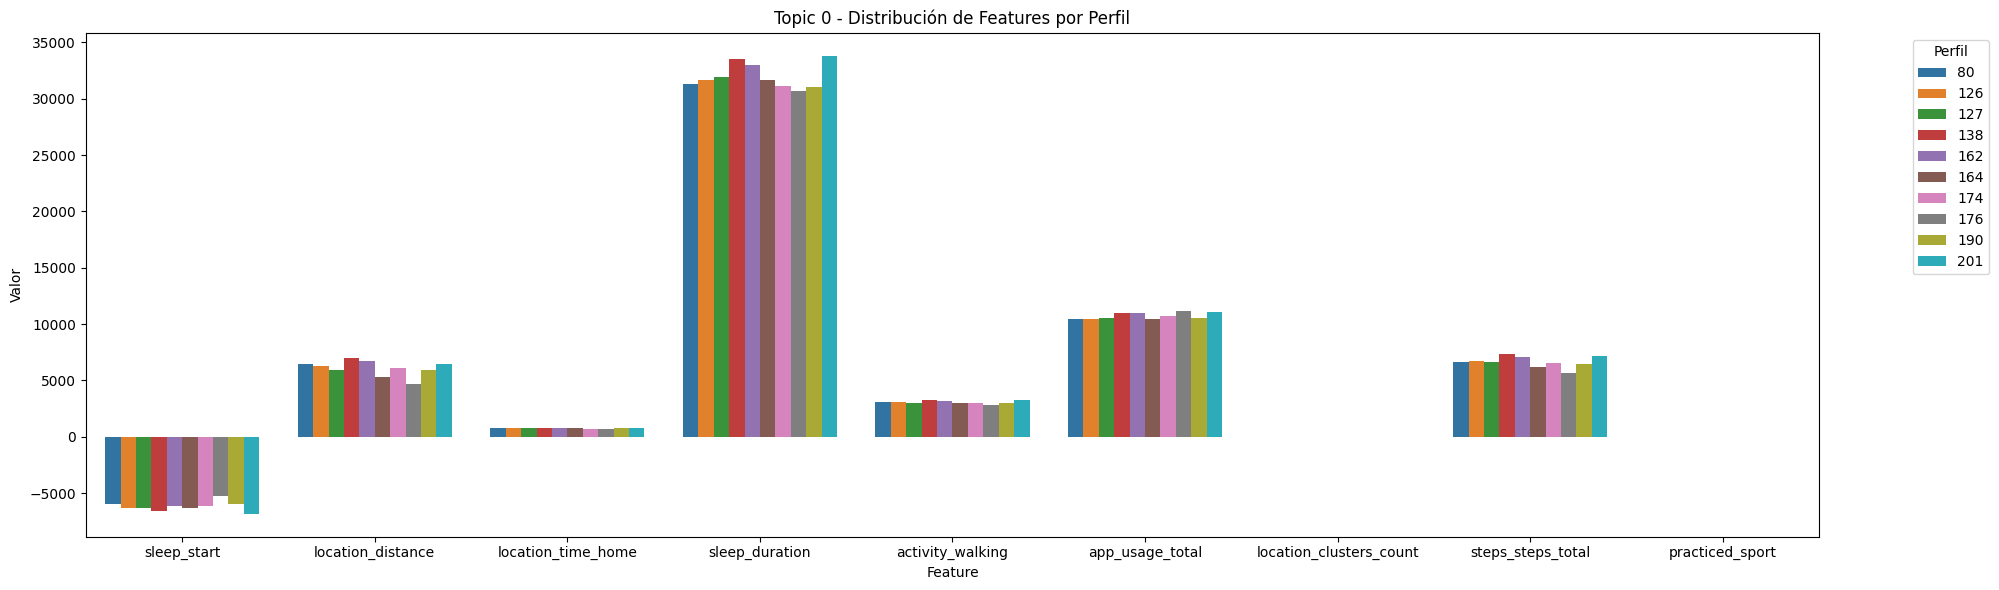

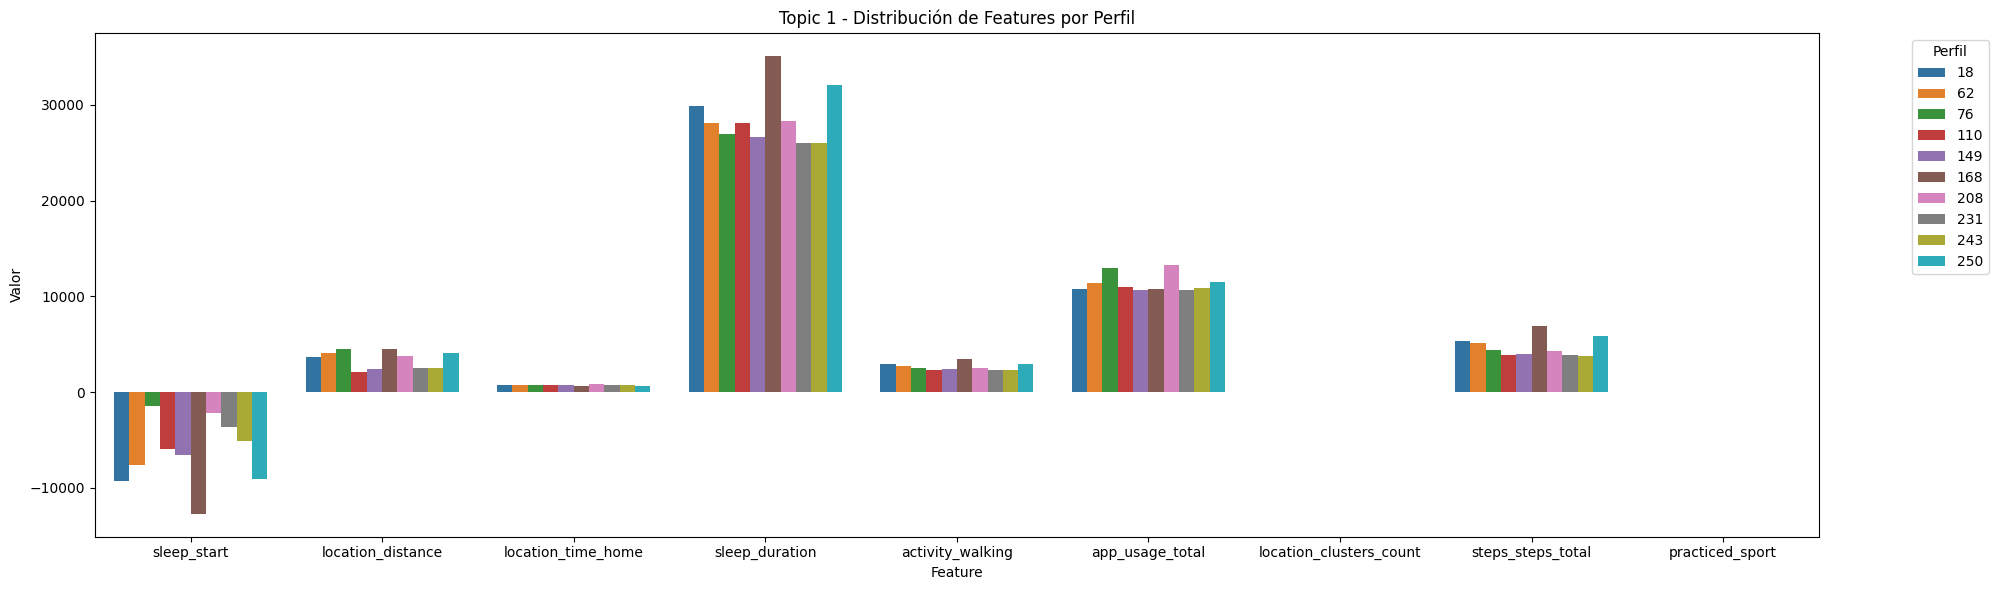

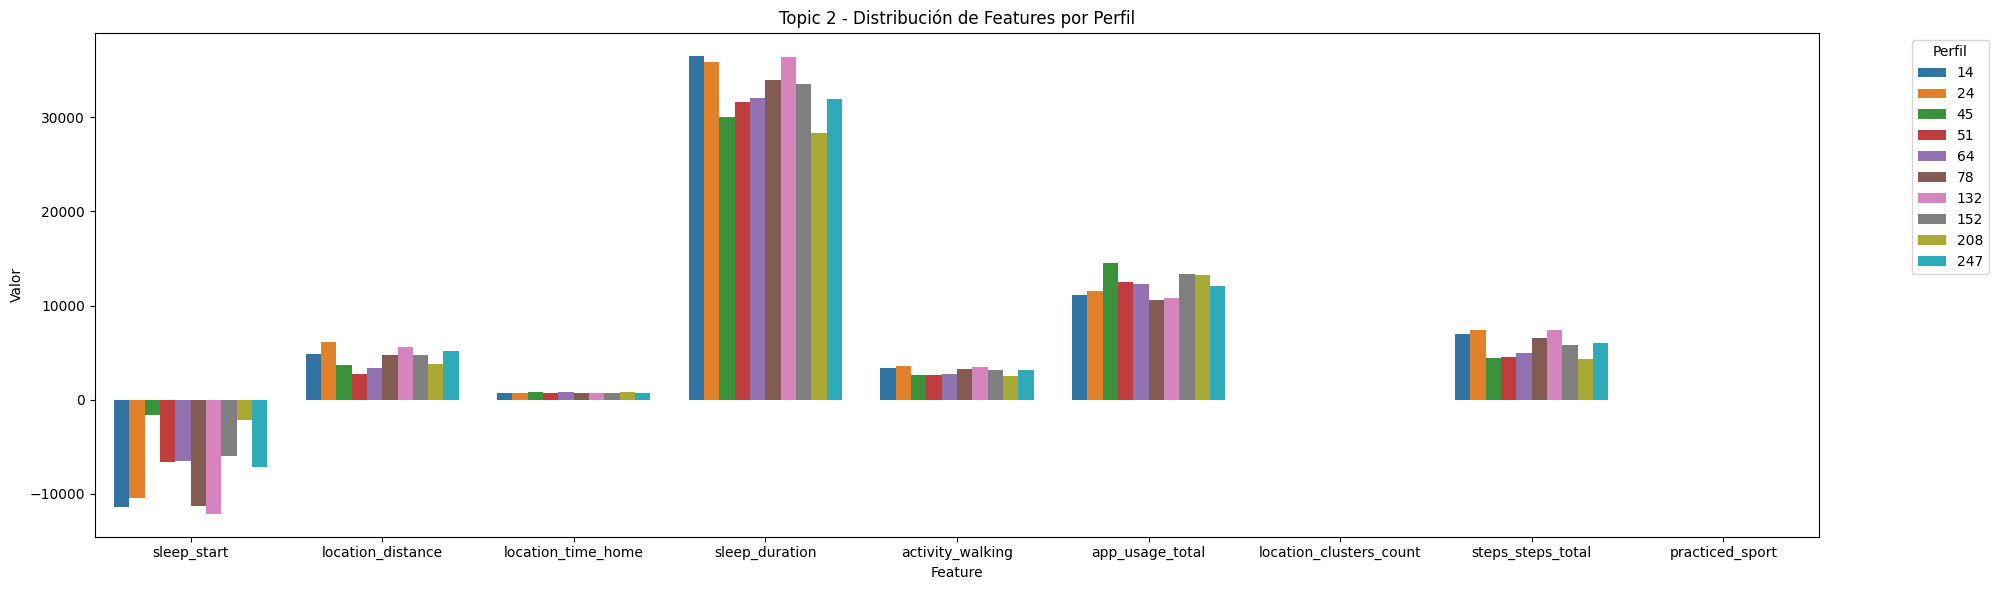

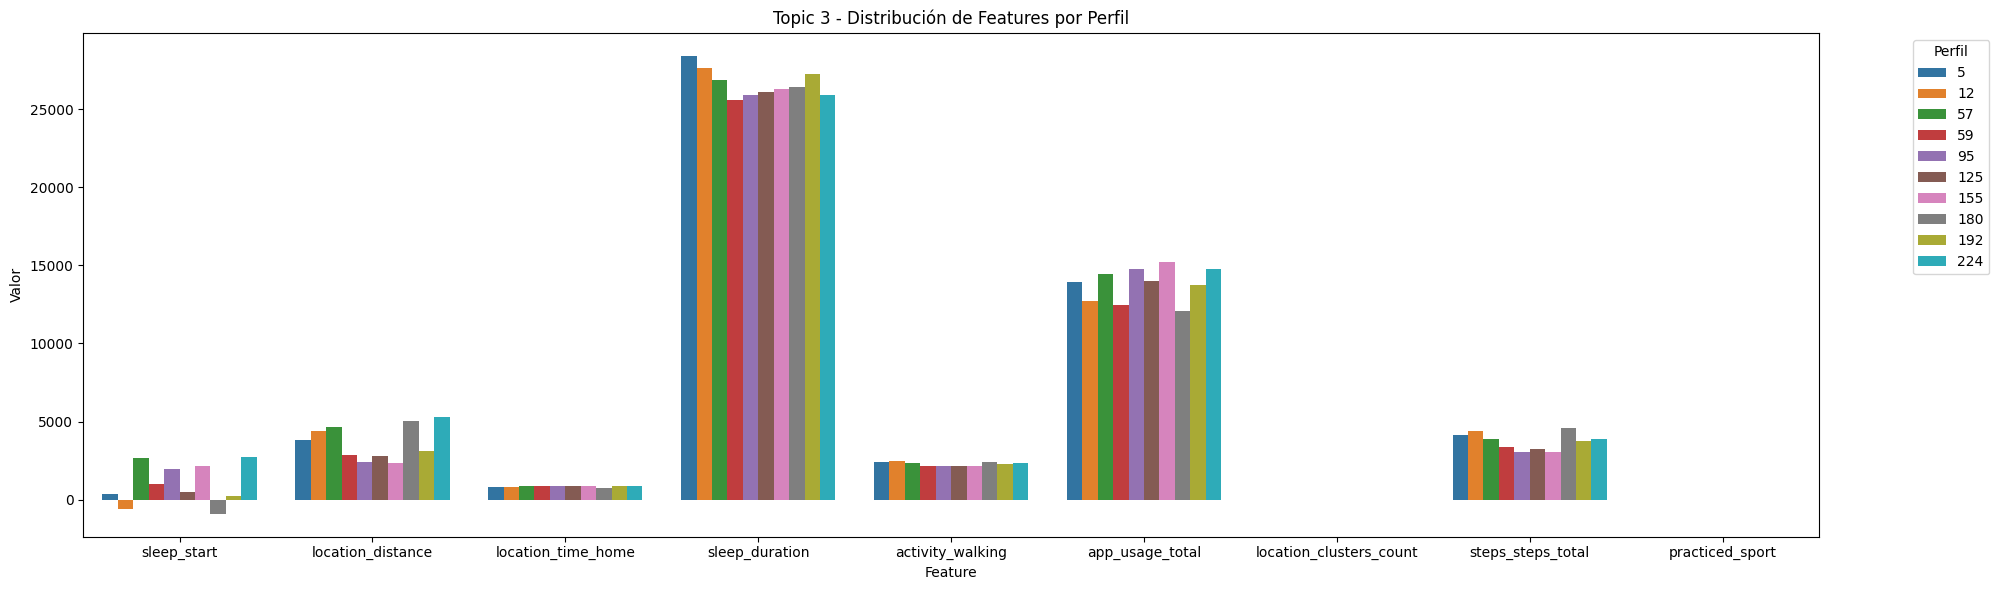

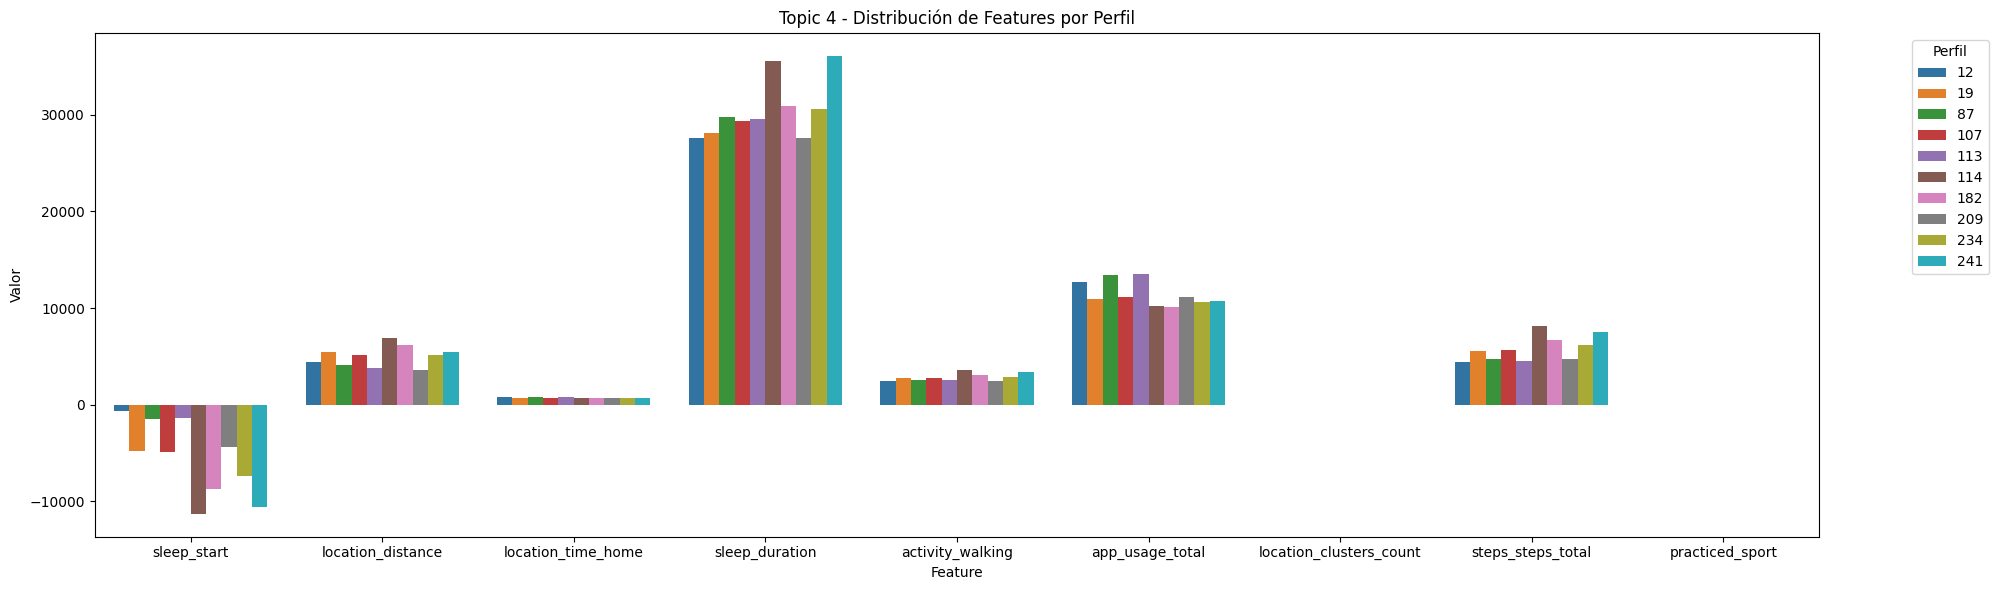

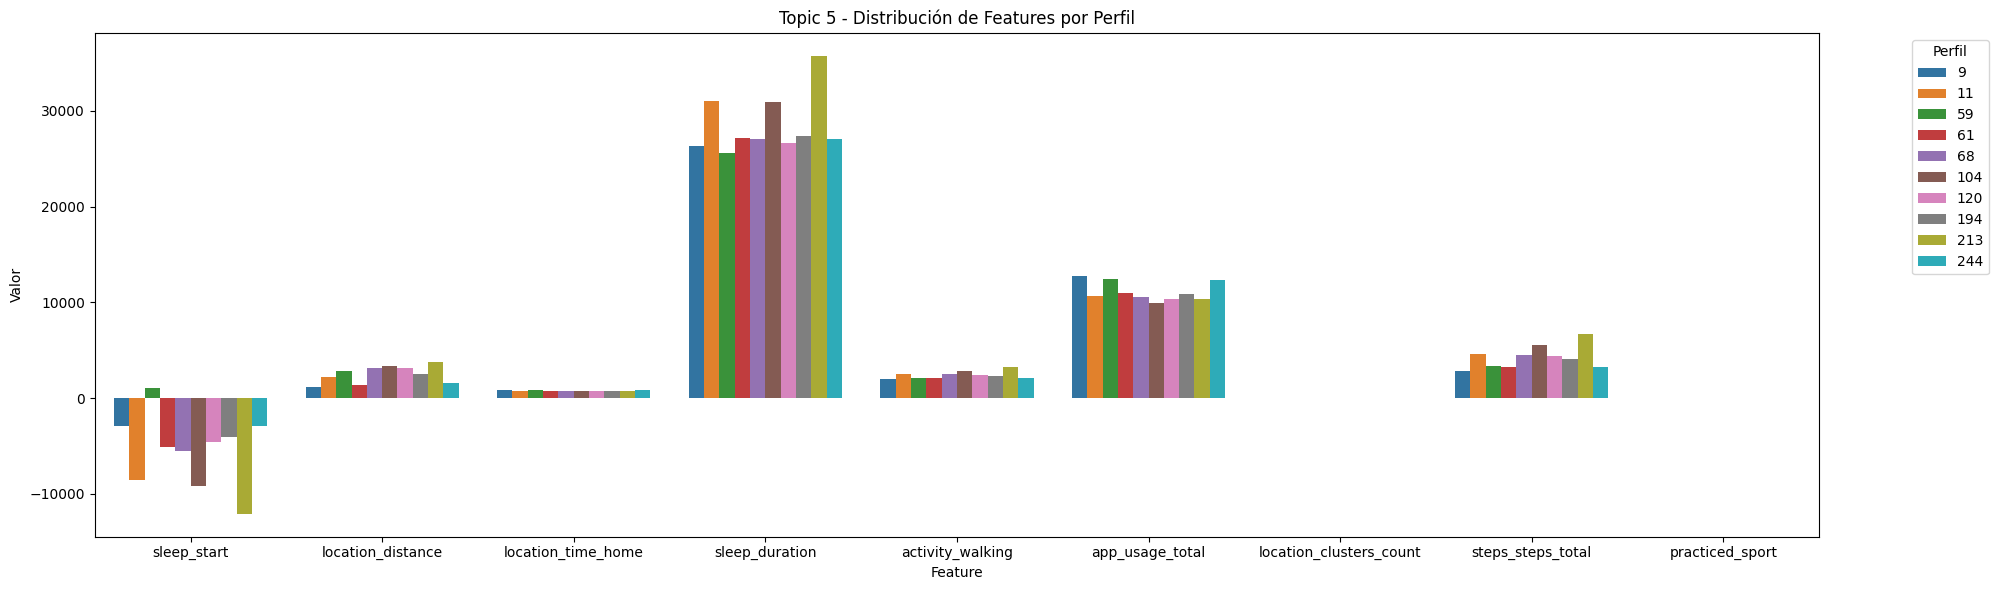

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Asumimos que tu DataFrame se llama df_final
feature_cols  = [
    "sleep_start",        # feat_0
    "location_distance",  # feat_1
    "location_time_home", # feat_2
    "sleep_duration",     # feat_3
    "activity_walking",   # feat_4
    "app_usage_total",    # feat_5
    "location_clusters_count", # feat_6
    "steps_steps_total",  # feat_7
    "practiced_sport"     # feat_9
    
]

# Para cada topic, hacemos un gráfico
for topic_id in df_final["topic"].unique():
    df_topic = df_final[df_final["topic"] == topic_id]

    # Convertimos a formato long para seaborn
    df_melted = df_topic.melt(id_vars=["profile"], value_vars=feature_cols,
                              var_name="Feature", value_name="Value")

    plt.figure(figsize=(20, 6))
    sns.barplot(data=df_melted, x="Feature", y="Value", hue="profile", palette="tab10")
    plt.title(f"Topic {topic_id} - Distribución de Features por Perfil")
    plt.ylabel("Valor")
    plt.xlabel("Feature")
    plt.legend(title="Perfil", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


# Normalizar datos

In [10]:
from sklearn.preprocessing import StandardScaler

# Seleccionar las columnas de características (sin la columna 'topic' y 'profile')
feature_columns = [col for col in df_final.columns if col not in ['topic', 'profile']]

# Creamos el scaler
scaler = StandardScaler()
df_final_scal=df_final
# Normalizamos las columnas seleccionadas
df_final_scal[feature_columns] = scaler.fit_transform(df_final_scal[feature_columns])

df_final_scal


,topic,profile,sleep_start,location_distance,location_time_home,sleep_duration,activity_walking,app_usage_total,location_clusters_count,steps_steps_total,practiced_sport
0,0,126,-0.322952,1.399459,-0.018849,0.541415,0.845010,-0.965096,0.370200,1.093270,-0.185695
1,0,80,-0.249284,1.532097,-0.070951,0.439860,0.786924,-0.968815,0.307877,1.060531,-0.185695
2,0,164,-0.326565,0.782520,0.065642,0.542025,0.658281,-0.936818,0.326646,0.752897,-0.185695
3,0,162,-0.291018,1.695829,-0.176086,0.972937,1.147686,-0.559411,0.372317,1.393000,-0.185695
4,0,127,-0.332979,1.160495,-0.119310,0.636424,0.760569,-0.910819,0.327266,1.047048,-0.185695
5,0,201,-0.451762,1.566820,-0.186289,1.220743,1.278111,-0.506841,0.480937,1.407293,-0.185695
6,0,190,-0.245958,1.148258,-0.143583,0.360442,0.660698,-0.904841,0.298298,0.897757,-0.185695
7,0,174,-0.293152,1.270127,-0.517975,0.384432,0.728069,-0.739809,0.398691,0.975184,-0.185695
8,0,176,-0.059935,0.309793,-0.392706,0.252936,0.169280,-0.466506,0.056086,0.361166,-0.185695
9,0,138,-0.386263,1.880289,-0.172228,1.135453,1.336998,-0.551193,0.475060,1.546003,-0.185695


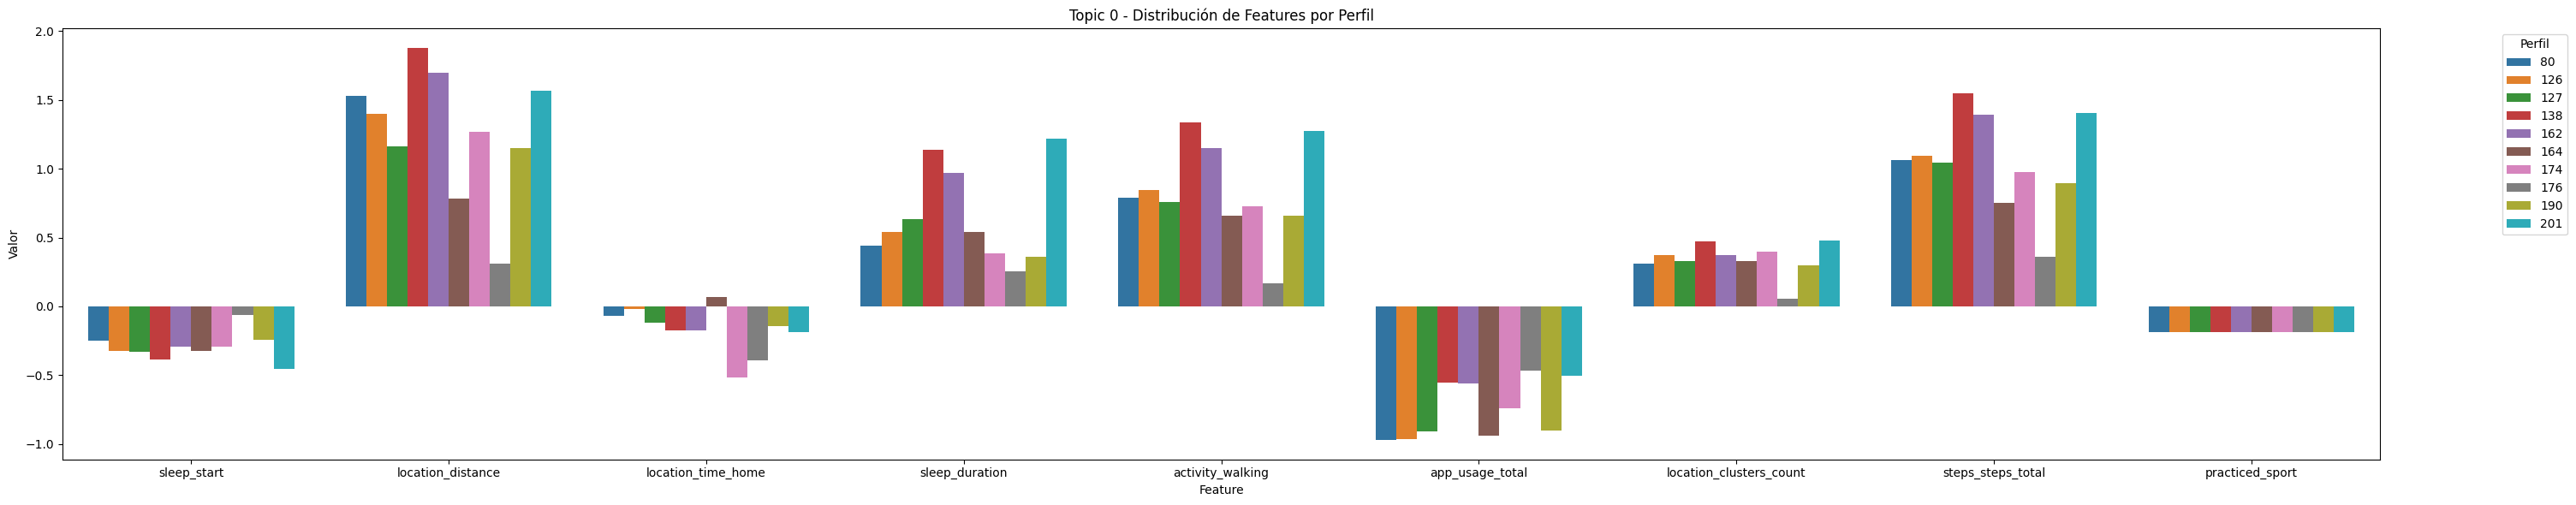

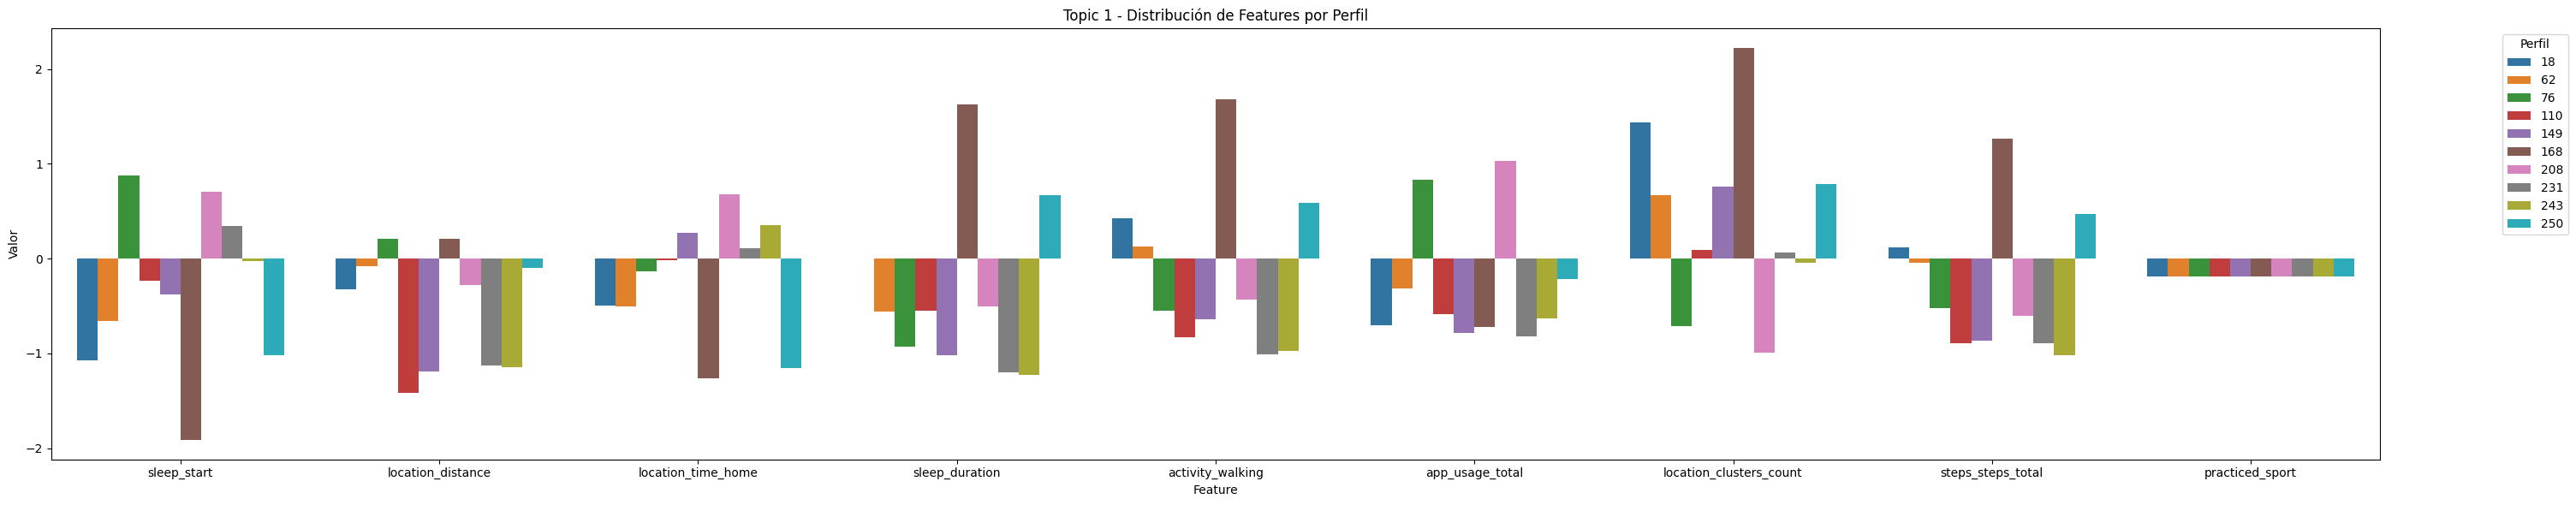

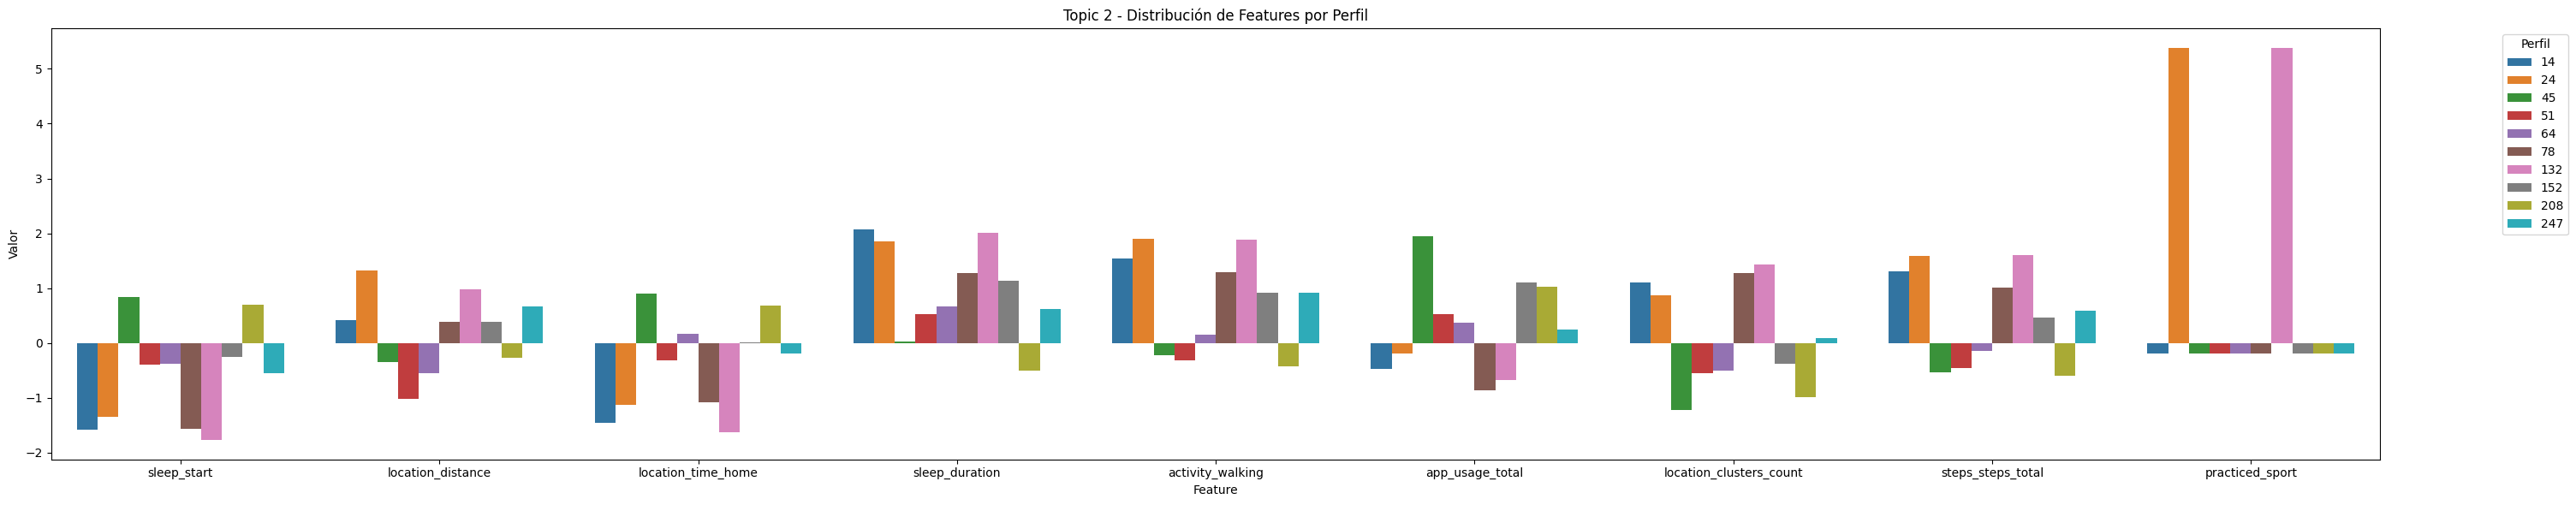

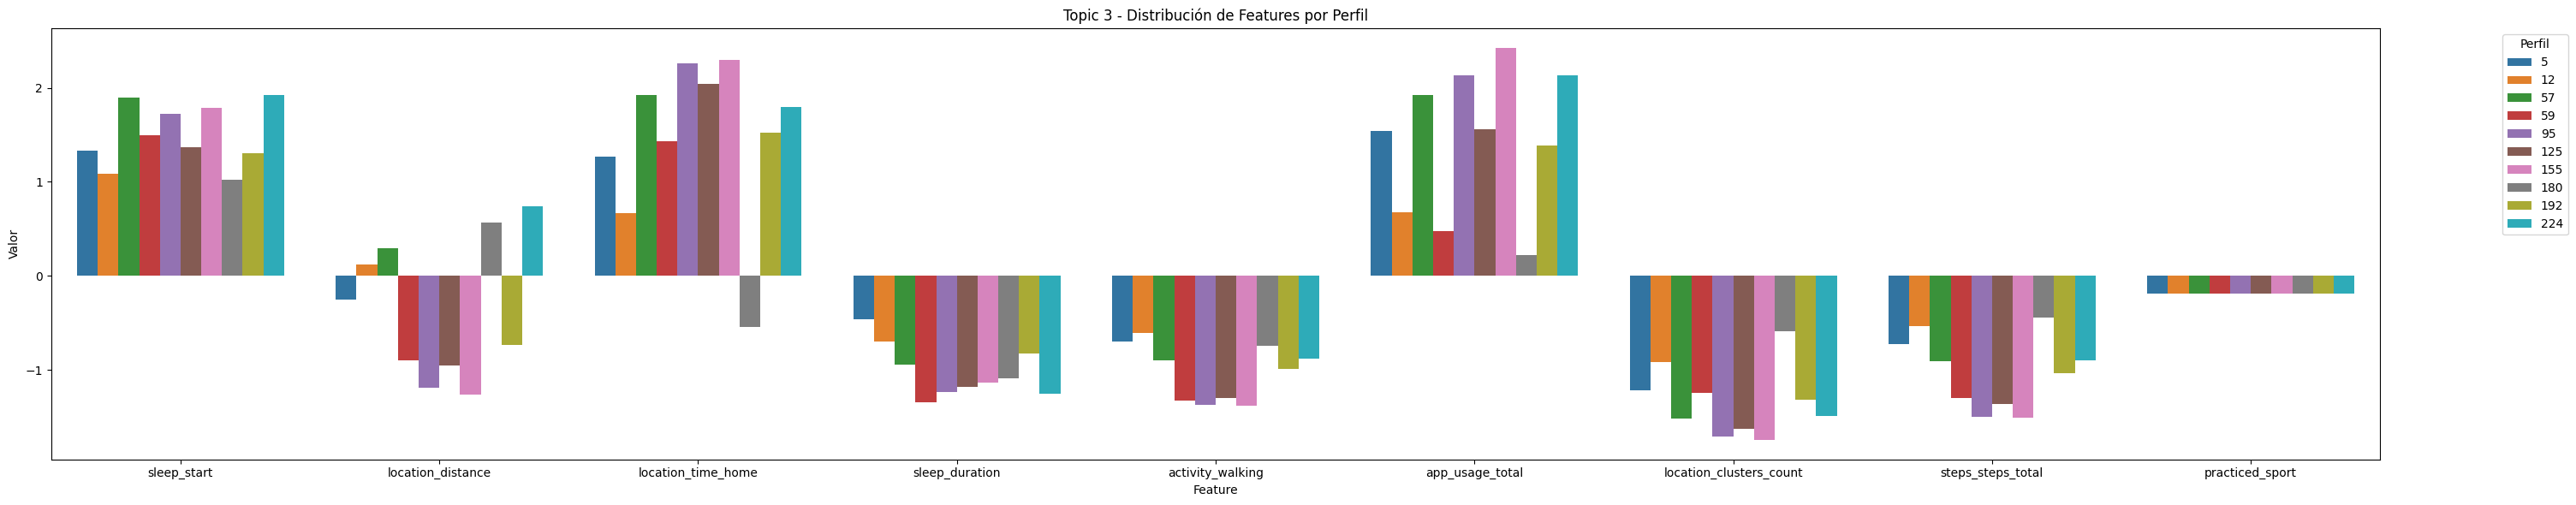

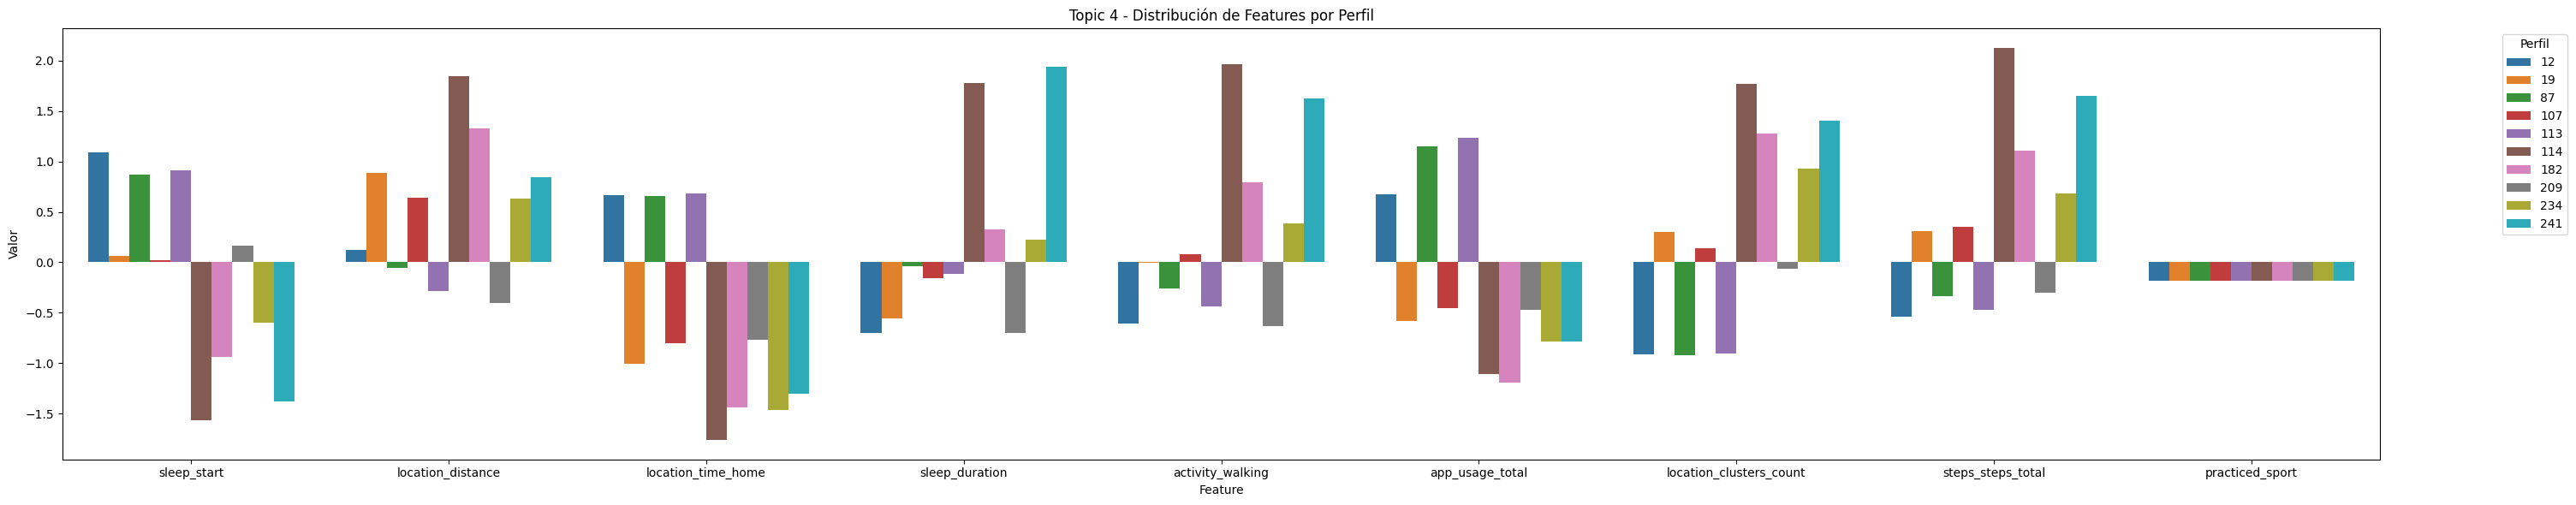

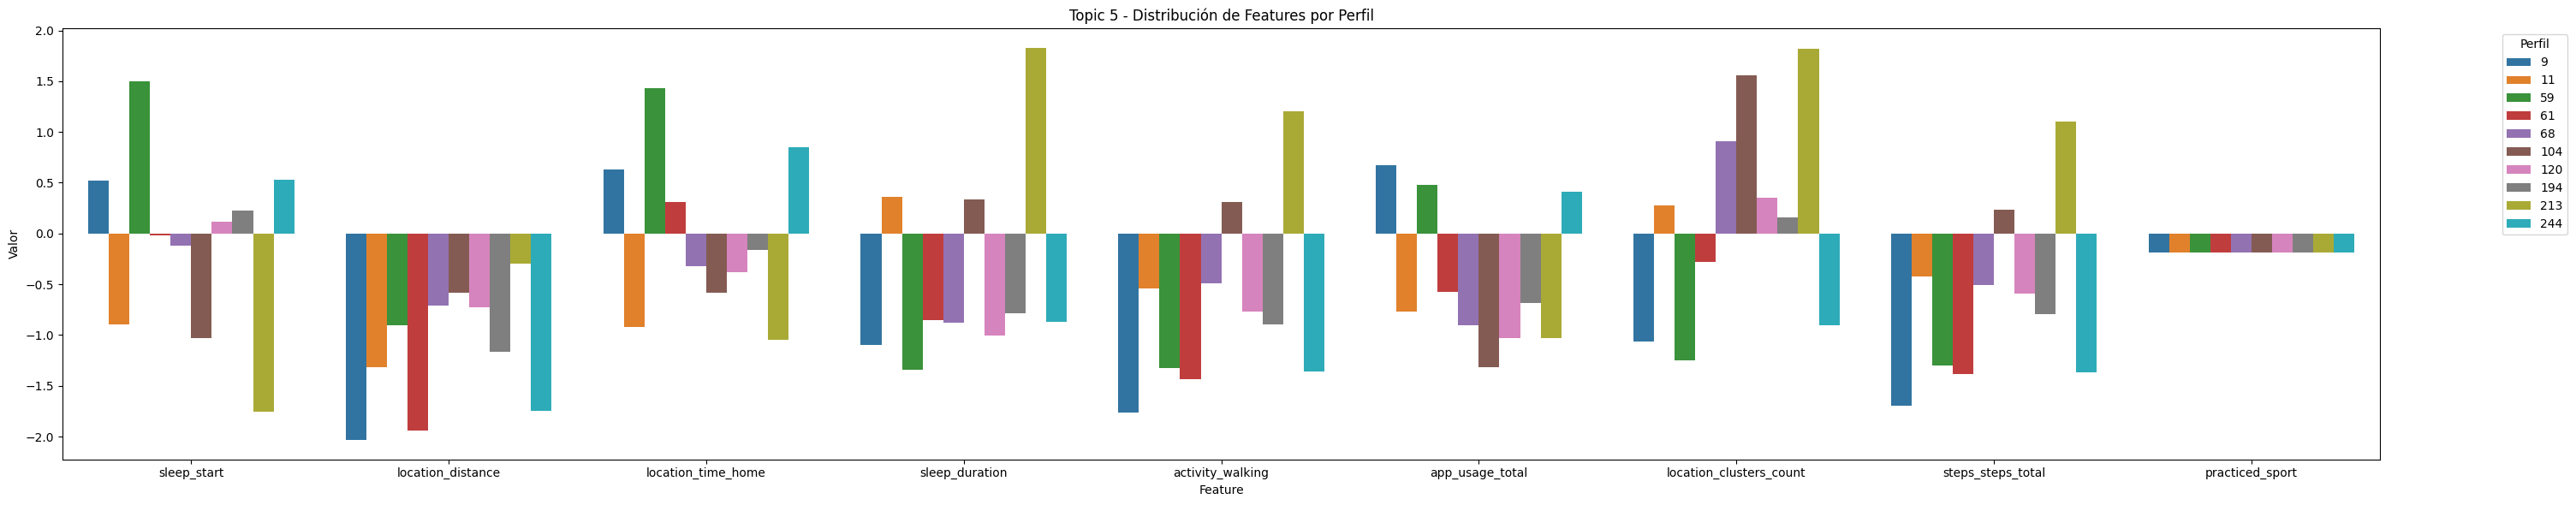

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

feature_cols  = [
    "sleep_start",        # feat_0
    "location_distance",  # feat_1
    "location_time_home", # feat_2
    "sleep_duration",     # feat_3
    "activity_walking",   # feat_4
    "app_usage_total",    # feat_5
    "location_clusters_count", # feat_6
    "steps_steps_total",  # feat_7
    "practiced_sport"     # feat_9
    
]

# Para cada topic, hacemos un gráfico
for topic_id in df_final["topic"].unique():
    df_topic = df_final[df_final["topic"] == topic_id]

    # Convertimos a formato long para seaborn
    df_melted = df_topic.melt(id_vars=["profile"], value_vars=feature_cols,
                              var_name="Feature", value_name="Value")

    plt.figure(figsize=(30, 6))
    sns.barplot(data=df_melted, x="Feature", y="Value", hue="profile", palette="tab10")
    plt.title(f"Topic {topic_id} - Distribución de Features por Perfil")
    plt.ylabel("Valor")
    plt.xlabel("Feature")
    plt.legend(title="Perfil", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


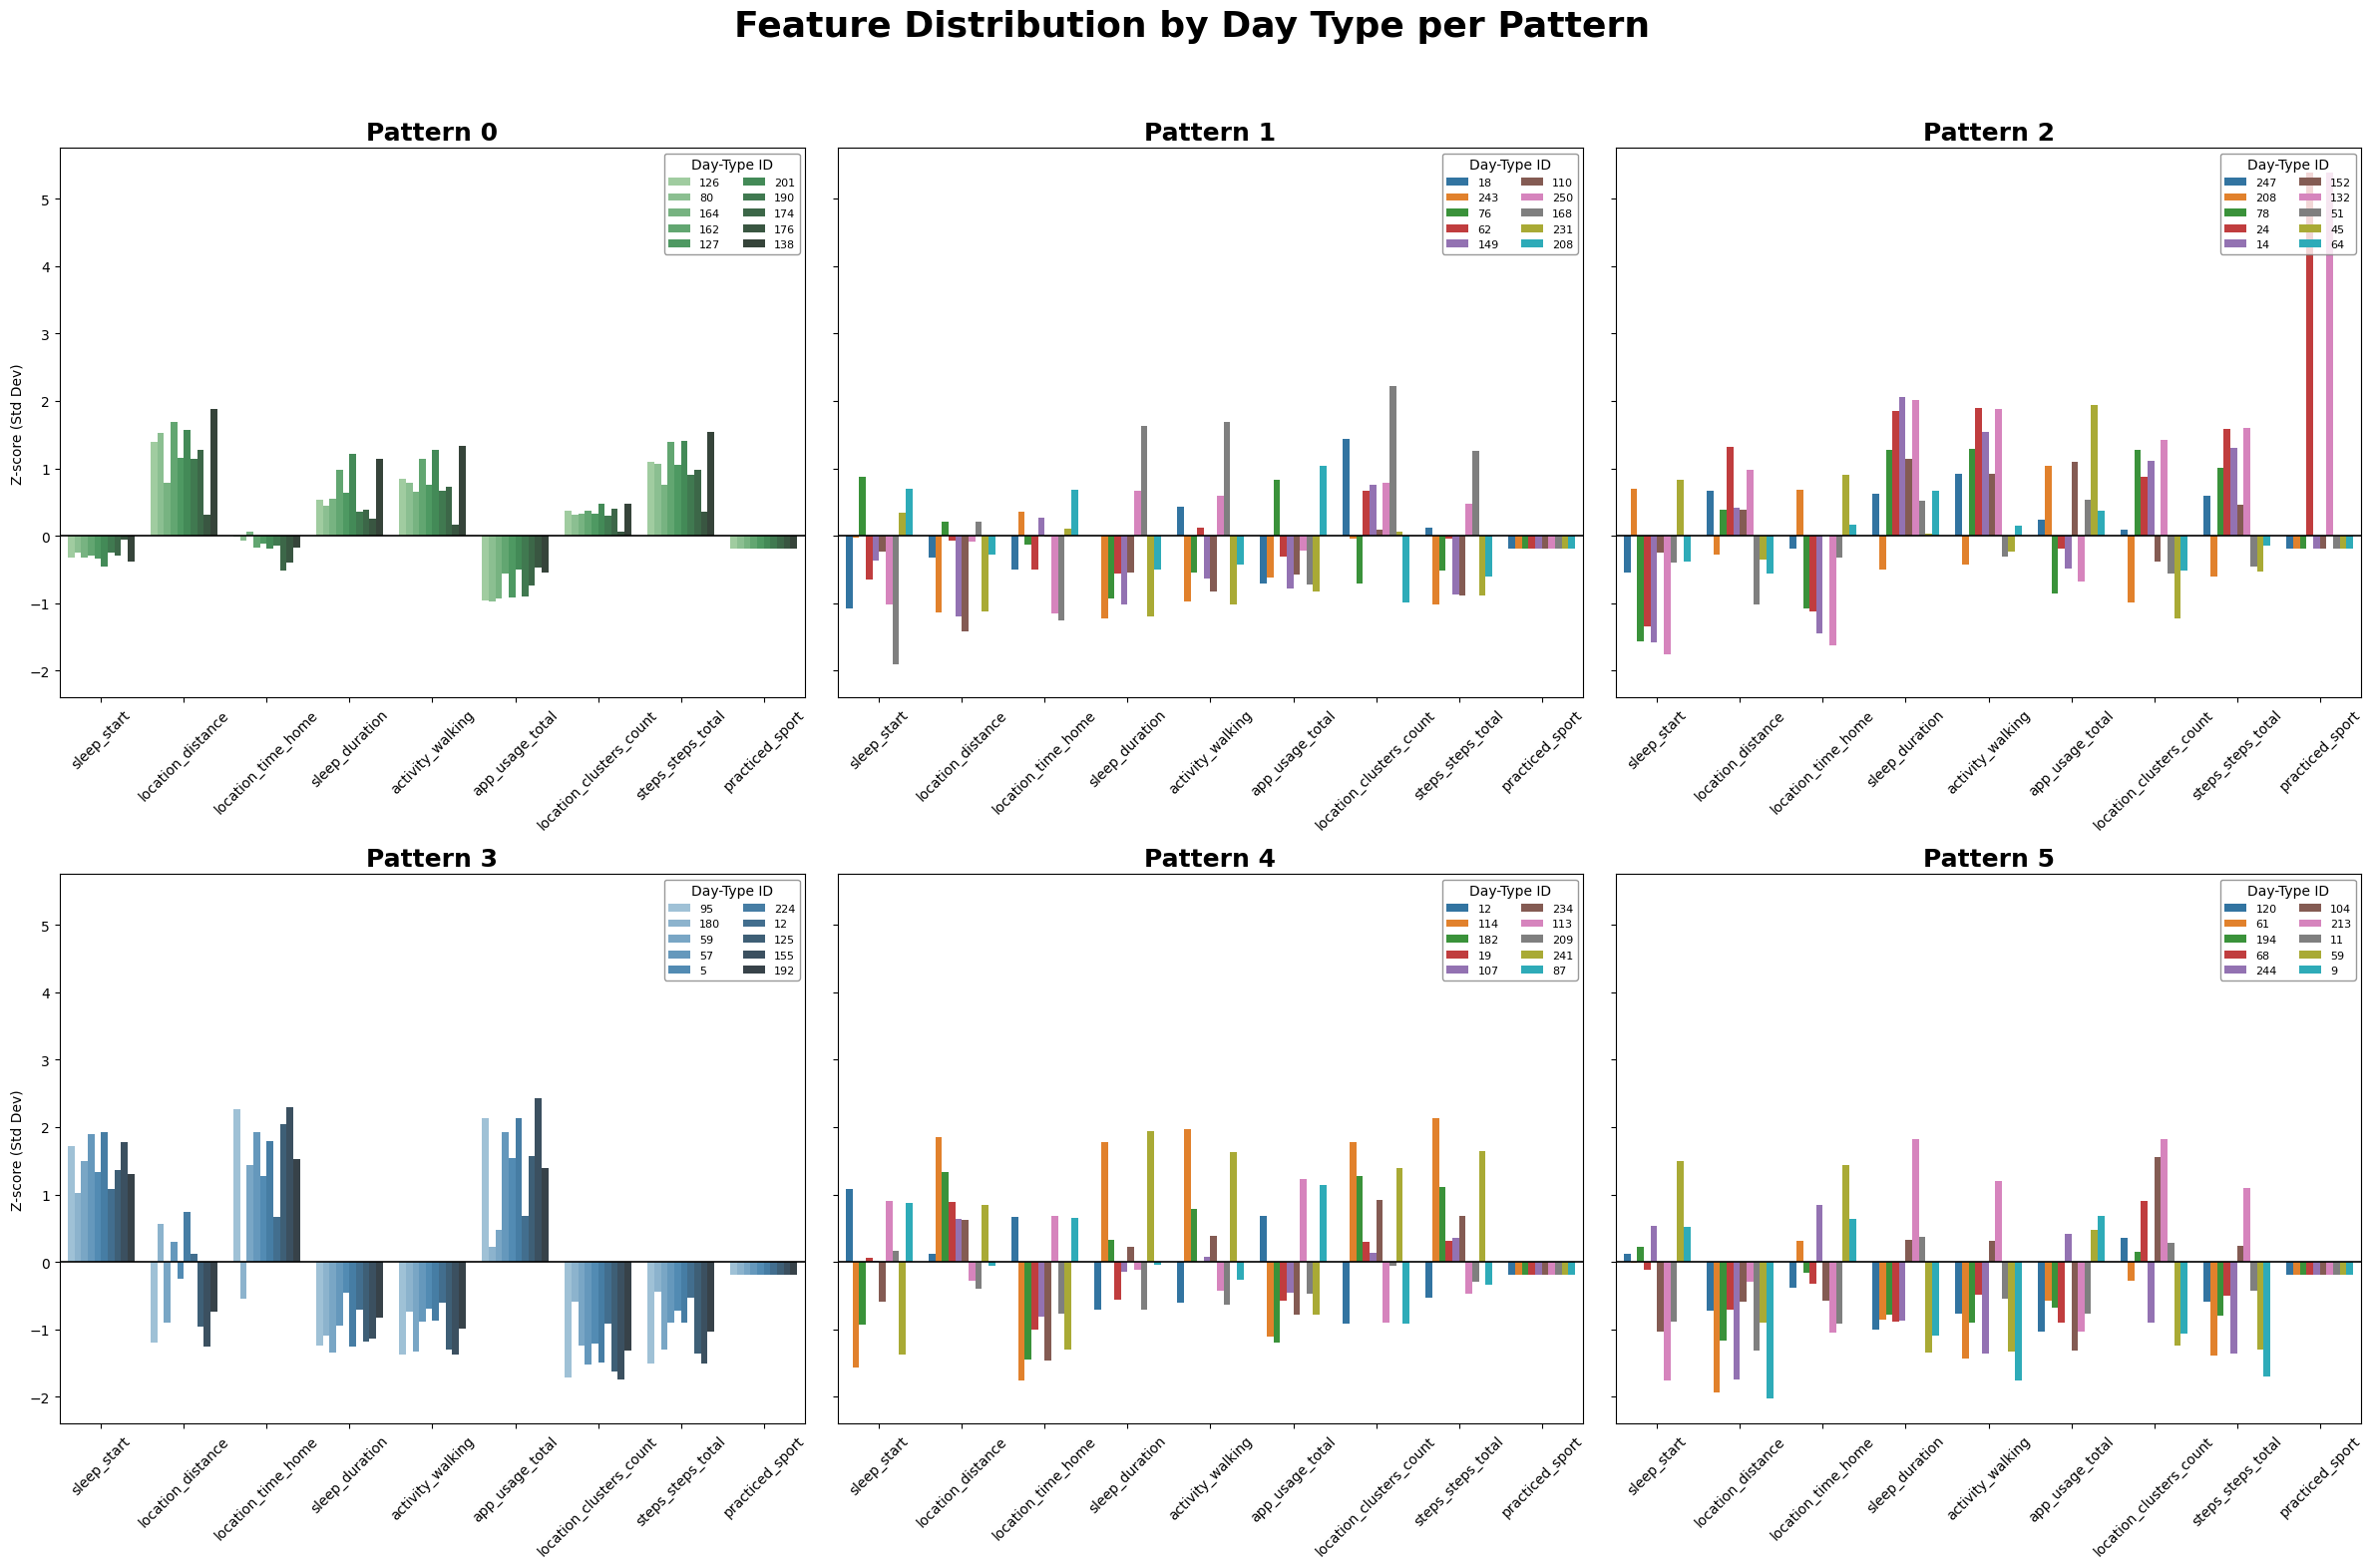

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- Configuración de Colores ---
palette_map = {
    0: "Greens_d", 
    3: "Blues_d",
}
default_palette = "tab10"

# --- Grid Configuration ---
topics = sorted(df_final["topic"].unique())
n_topics = len(topics)
n_cols = 3
n_rows = (n_topics + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 16), sharey=True)
axes = axes.flatten()

for i, topic_id in enumerate(topics):
    ax = axes[i]
    df_topic = df_final[df_final["topic"] == topic_id].copy()

    # SOLUCIÓN 1: Convertir 'profile' a string para que no se pierda ninguno
    df_topic['profile'] = df_topic['profile'].astype(str)

    # Convert to long format
    df_melted = df_topic.melt(
        id_vars=["profile"], 
        value_vars=feature_cols,
        var_name="Feature", 
        value_name="Value"
    )

    current_palette = palette_map.get(topic_id, default_palette)

    # Dibujar Barplot
    # Usamos sort=False para mantener el orden original de tus perfiles
    sns.barplot(
        data=df_melted, 
        x="Feature", 
        y="Value", 
        hue="profile", 
        palette=current_palette, 
        ax=ax
    )

    # Ajustes estéticos
    ax.set_title(f"Pattern {topic_id}", fontsize=18, fontweight='bold')
    ax.set_ylabel("Z-score (Std Dev)" if i % n_cols == 0 else "")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.axhline(0, color='black', linewidth=1.2)
    
    # SOLUCIÓN 2: Forzar la leyenda a mostrar los 10 elementos
    # La movemos un poco para que no tape las barras y usamos 2 columnas
    ax.legend(
        title="Day-Type ID", 
        loc='upper right', # O 'lower right' si las barras crecen hacia arriba
        fontsize='8', 
        ncol=2, 
        frameon=True,
        edgecolor='gray'
    )

# Eliminar subplots vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Feature Distribution by Day Type per Pattern", fontsize=26, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Guardado
output_path = module_path + '/2nd_phase/results/decoded_topic_plots/decoded_top10_lda_patterns_fixed.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

✅ Image saved at: /export/gts_usuarios/lparbaiza/cnio/2nd_phase/results/decoded_topic_plots/decoded_top10_lda_patterns.png


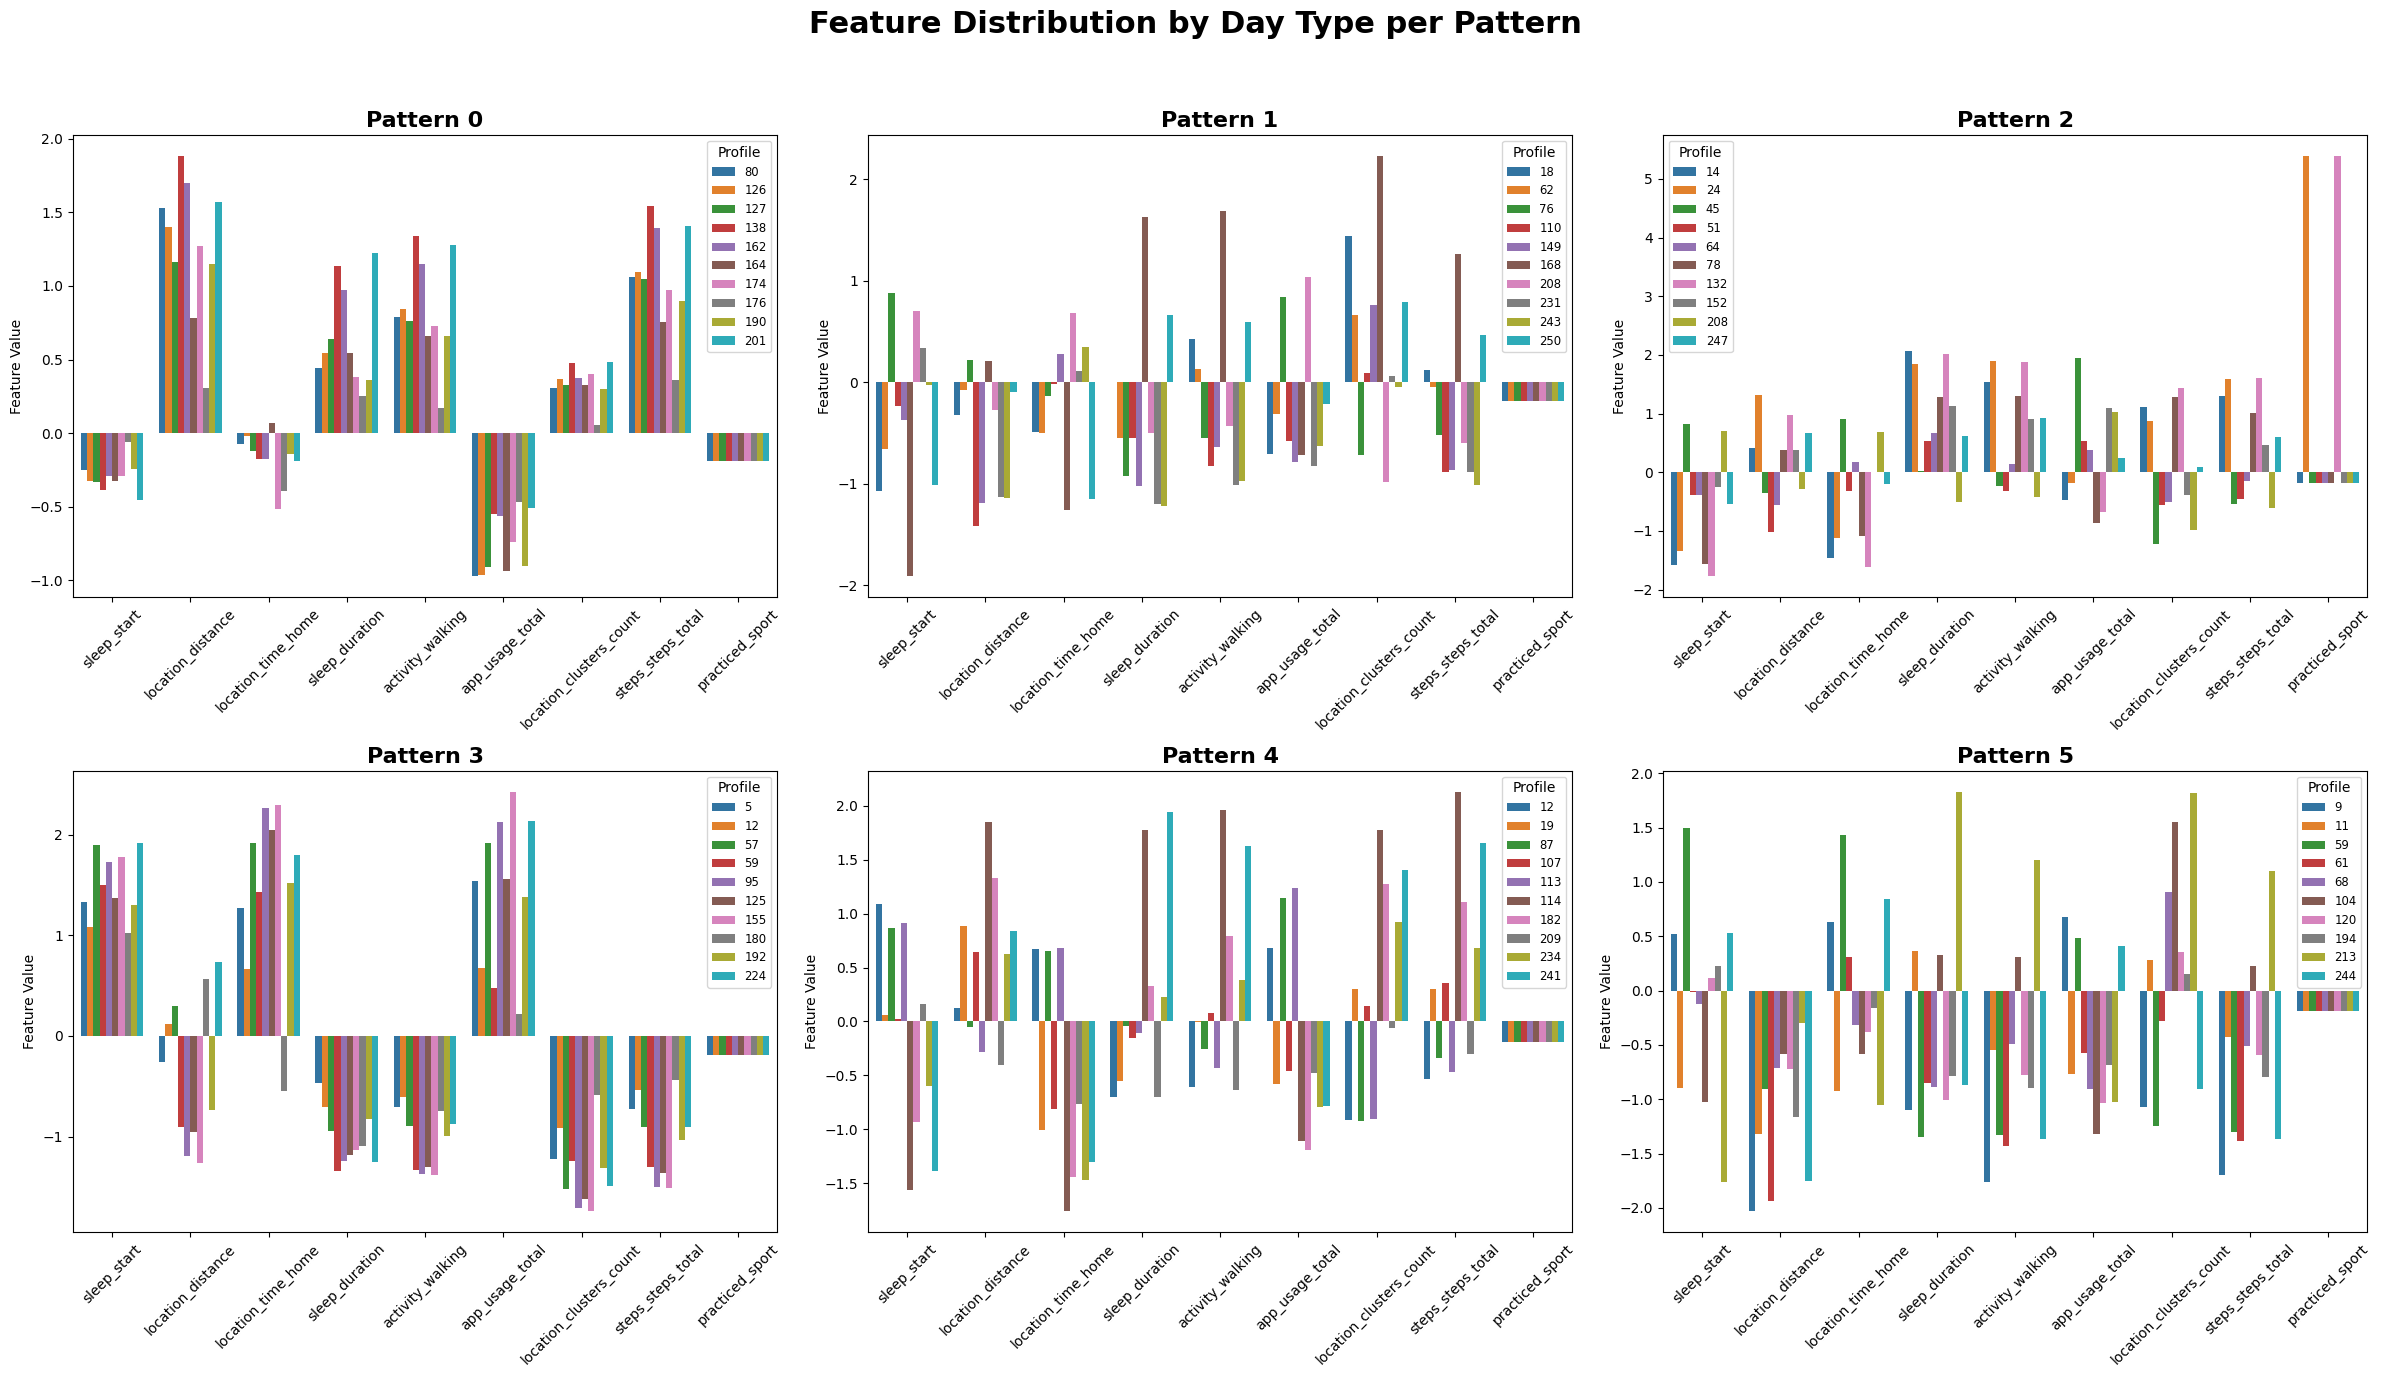

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os

# --- Grid Configuration ---
topics = sorted(df_final["topic"].unique())
n_topics = len(topics)
n_cols = 3
n_rows = (n_topics + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 14), sharey=False)
axes = axes.flatten()

# --- Plotting Loop ---
for i, topic_id in enumerate(topics):
    ax = axes[i]
    df_topic = df_final[df_final["topic"] == topic_id]

    # Convert to long format for seaborn
    df_melted = df_topic.melt(
        id_vars=["profile"], 
        value_vars=feature_cols,
        var_name="Feature", 
        value_name="Value"
    )

    # Draw Barplot
    sns.barplot(
        data=df_melted, 
        x="Feature", 
        y="Value", 
        hue="profile", 
        palette="tab10", 
        ax=ax
    )

    # Aesthetic adjustments per subplot
    # Changed "Topic" to "Pattern" and adjusted to 1-based indexing if desired (topic_id + 1)
    ax.set_title(f"Pattern {topic_id }", fontsize=16, fontweight='bold')
    ax.set_ylabel("Feature Value")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45)
    
    # LEGEND: Now enabled for every subplot
    # 'best' automatically finds an empty space in each plot
    ax.legend(title="Profile", loc='best', fontsize='small')

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# --- Final Adjustments & Saving ---
plt.suptitle("Feature Distribution by Day Type per Pattern", fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the full image
output_path = module_path + '/2nd_phase/results/decoded_topic_plots/decoded_top10_lda_patterns.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✅ Image saved at: {output_path}")

plt.show()

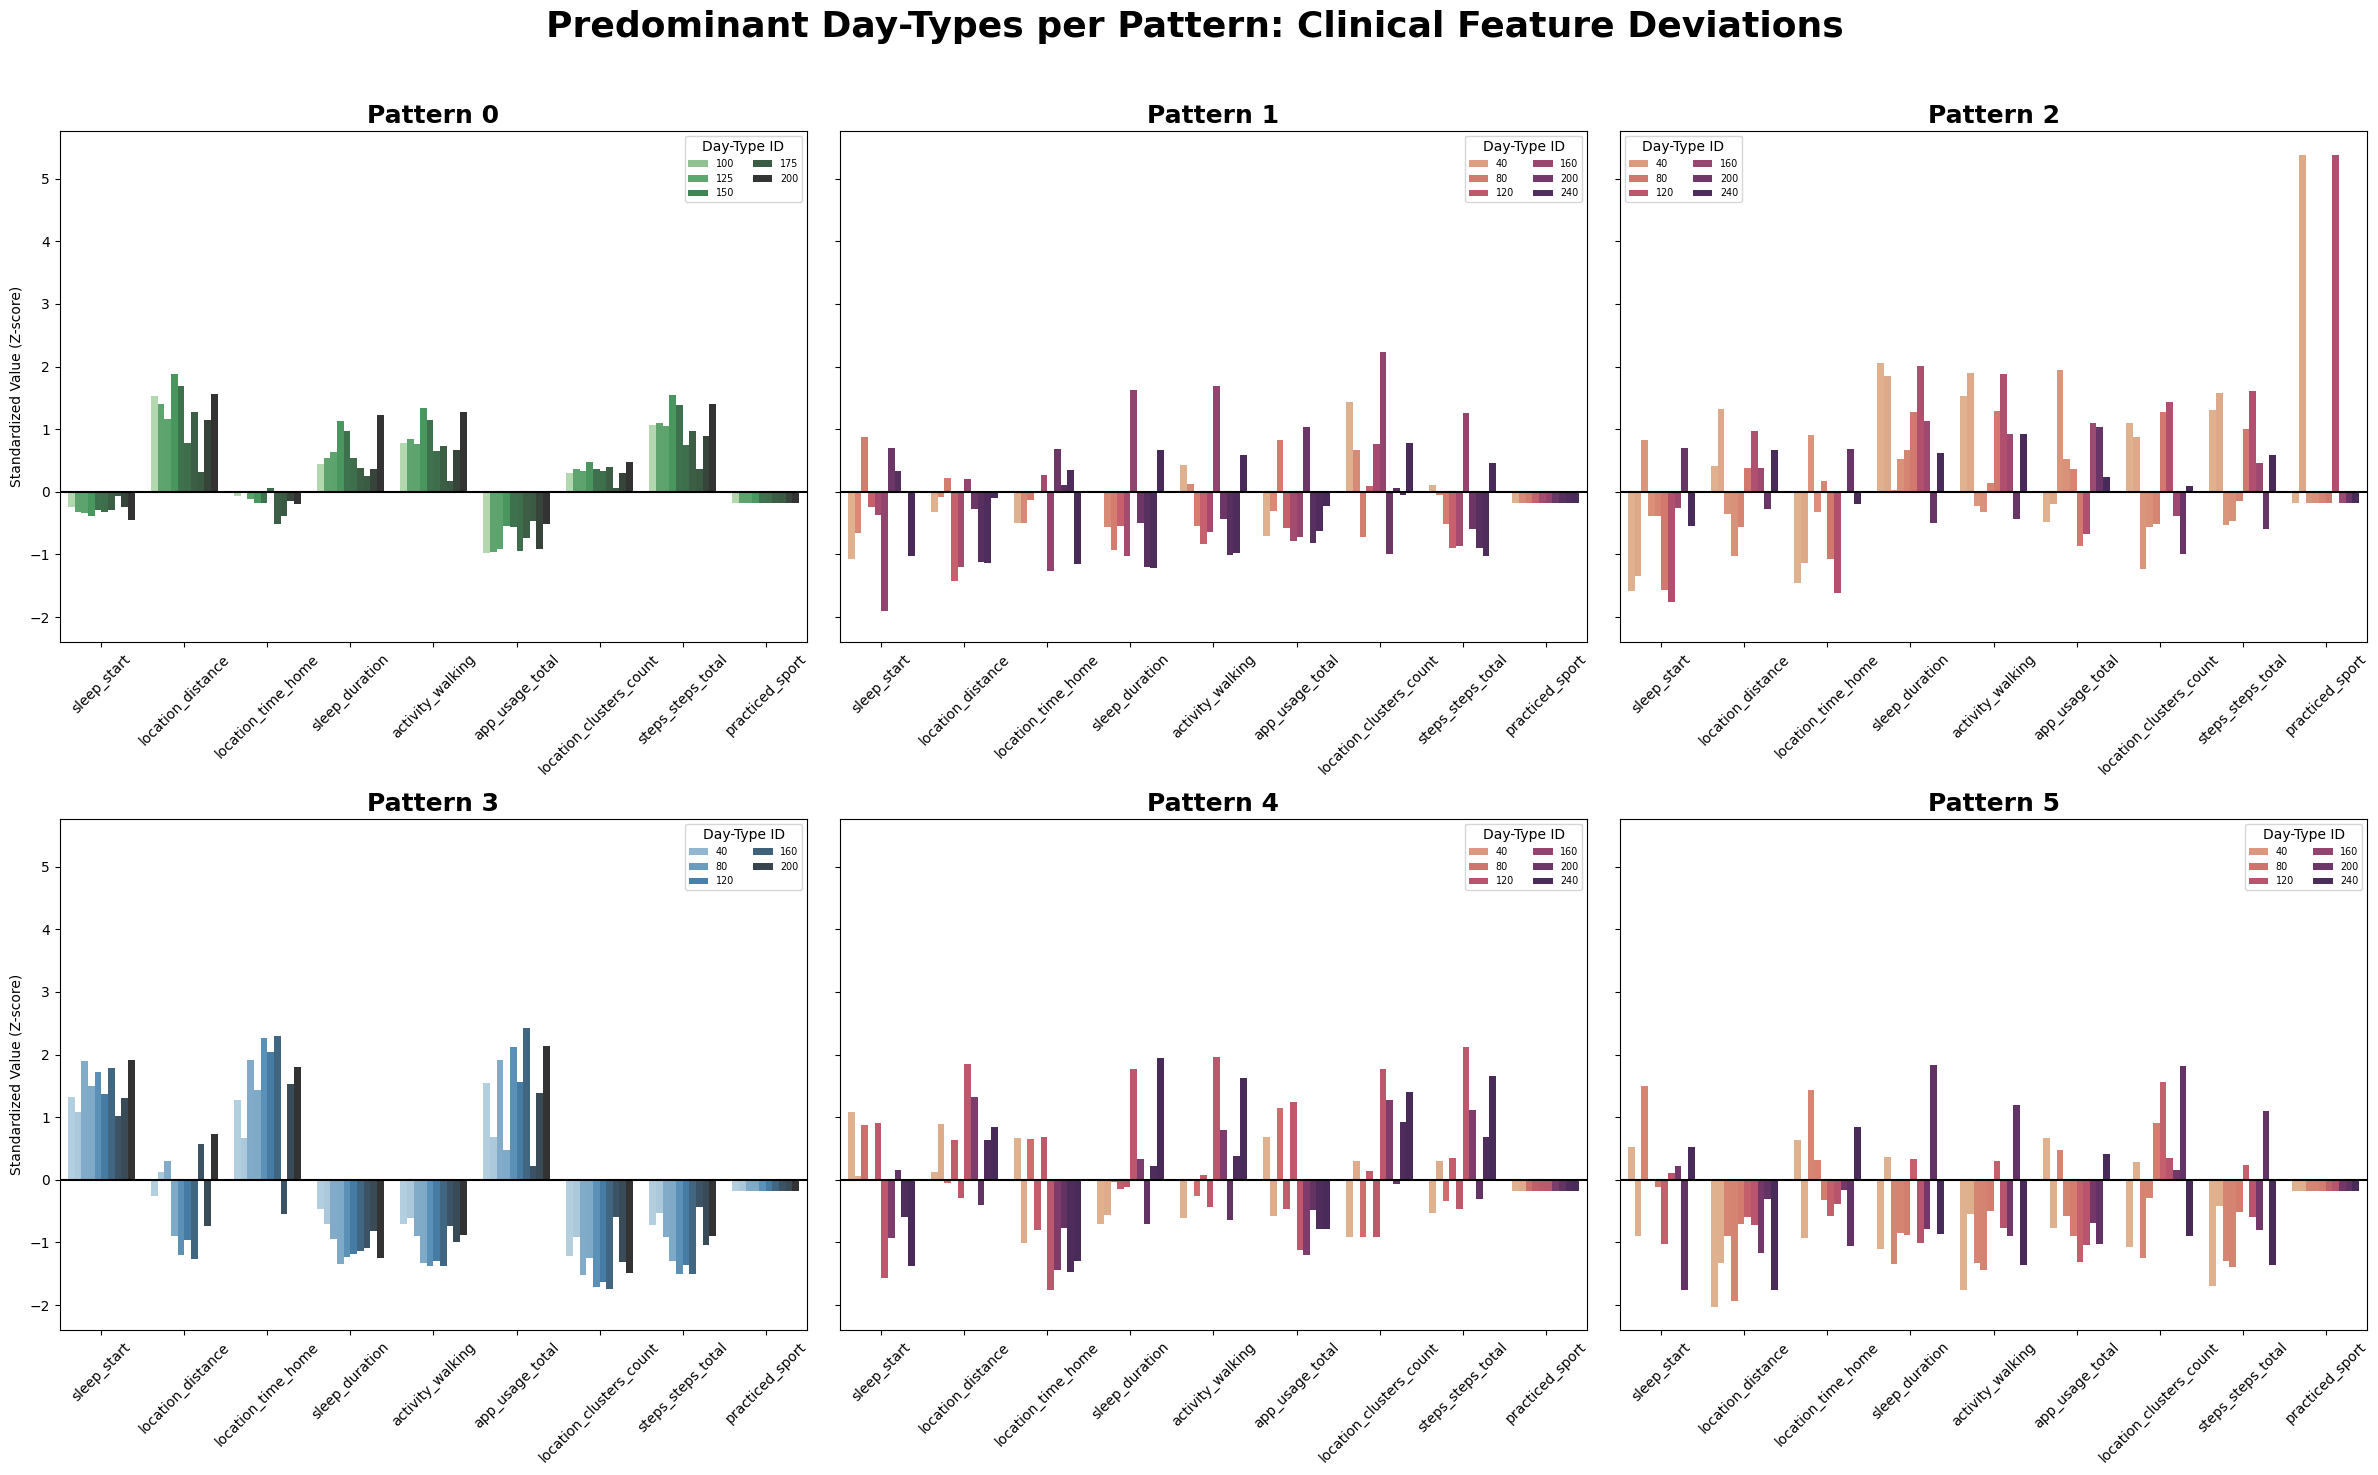

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. DEFINE YOUR COLOR STRATEGY
# Pattern 1 (ID 0) -> Shades of Green
# Pattern 4 (ID 3) -> Shades of Blue
# Others -> Default (e.g., 'rocket', 'mako', or 'viridis')
palette_map = {
    0: "Greens_d", 
    3: "Blues_d",
}
default_palette = "flare" 

# 2. GRID SETUP
topics = sorted(df_final["topic"].unique())
n_topics = len(topics)
n_cols = 3
n_rows = (n_topics + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 15), sharey=True)
axes = axes.flatten()

# 3. PLOTTING LOOP
for i, topic_id in enumerate(topics):
    ax = axes[i]
    
    # Filter data for this specific pattern
    df_topic = df_final[df_final["topic"] == topic_id]

    # Convert to long format for Seaborn
    df_melted = df_topic.melt(
        id_vars=["profile"], 
        value_vars=feature_cols, # Use your list of clinical parameters
        var_name="Feature", 
        value_name="Z-score"
    )

    # Pick the custom palette or the default one
    current_palette = palette_map.get(topic_id, default_palette)

    # Create the Barplot
    sns.barplot(
        data=df_melted, 
        x="Feature", 
        y="Z-score", 
        hue="profile", 
        palette=current_palette, 
        ax=ax
    )

    # --- AESTHETICS ---
    # Title: Pattern 1, Pattern 2, etc.
    ax.set_title(f"Pattern {topic_id }", fontsize=18, fontweight='bold')
    
    # Labels (English)
    ax.set_ylabel("Standardized Value (Z-score)" if i % 3 == 0 else "")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    
    # Baseline at 0 (essential for Z-scores)
    ax.axhline(0, color='black', linewidth=1.5, linestyle='-')
    
    # Legend: Unique for each subplot to show specific Day-Type IDs
    ax.legend(title="Day-Type ID", loc='best', fontsize='x-small', ncol=2)

# 4. CLEANUP & TITLES
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Predominant Day-Types per Pattern: Clinical Feature Deviations", 
             fontsize=26, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# 5. SAVE
plt.savefig("final_pattern_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

Saved individual plot: /export/gts_usuarios/lparbaiza/cnio/2nd_phase/results/decoded_topic_plots/pattern_0_individual.svg
Saved individual plot: /export/gts_usuarios/lparbaiza/cnio/2nd_phase/results/decoded_topic_plots/pattern_3_individual.svg
Saved main grid plot: /export/gts_usuarios/lparbaiza/cnio/2nd_phase/results/decoded_topic_plots/final_pattern_analysis_grid.svg


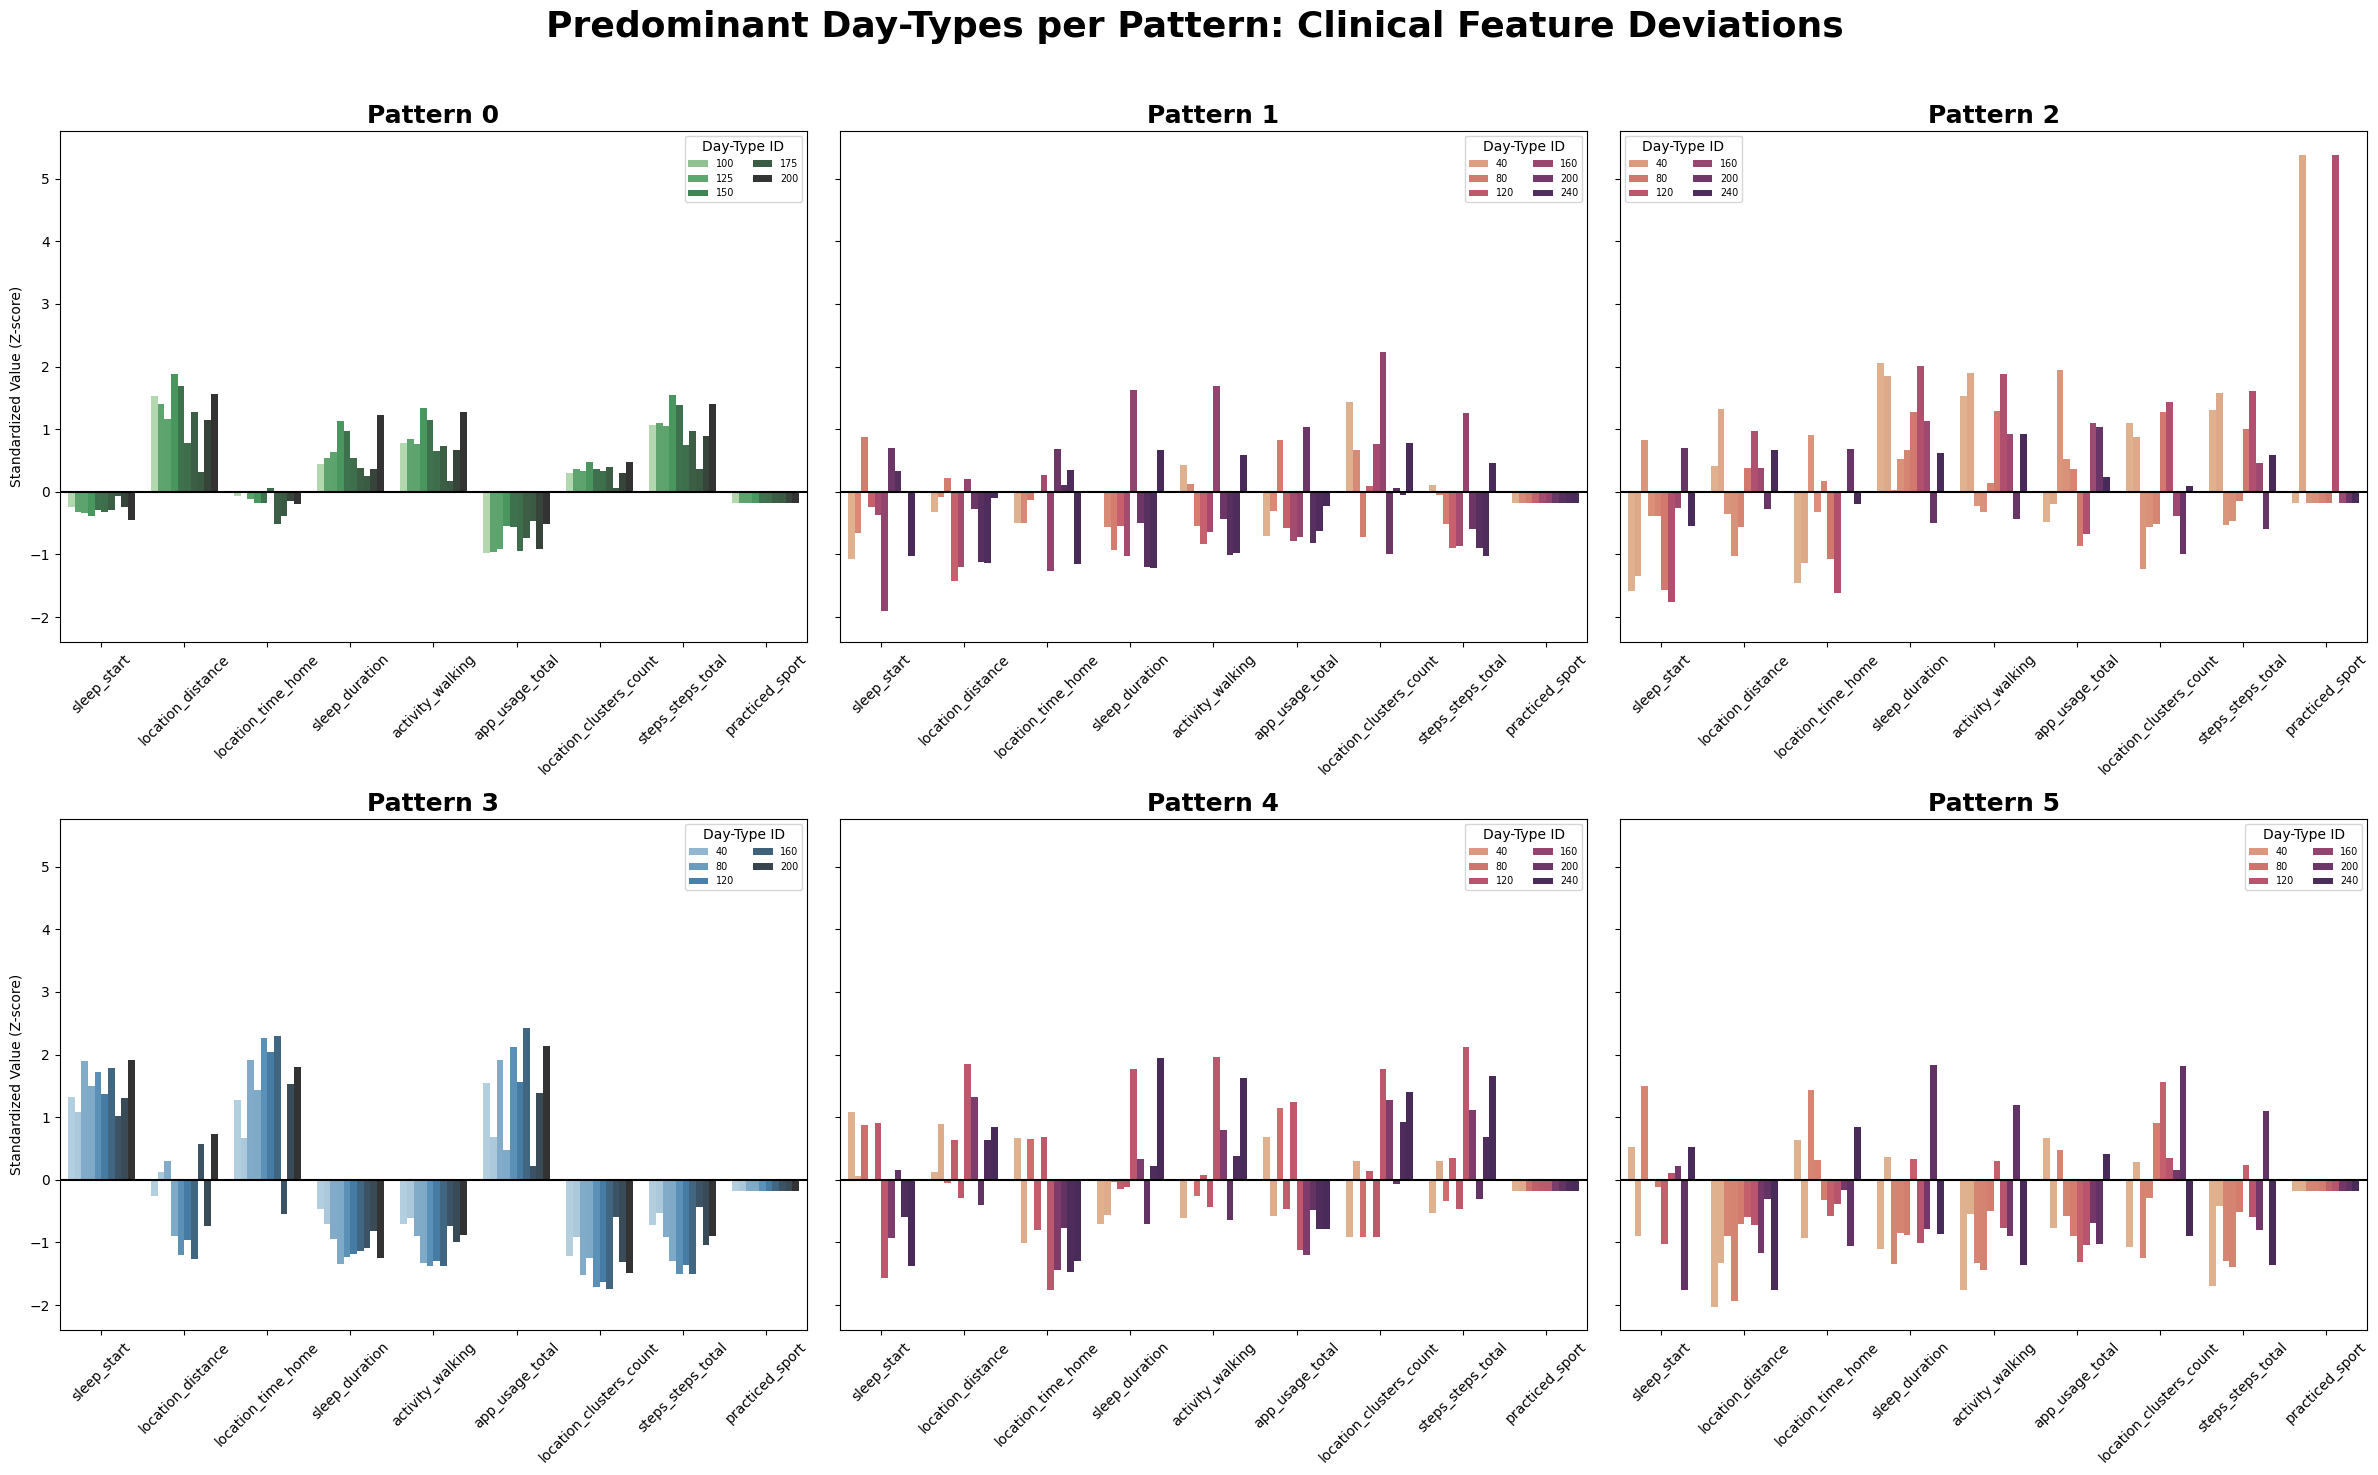

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

# --- PREPARACIÓN PARA GUARDAR ---
# Define aquí la carpeta donde quieres guardar los SVG

save_dir = os.path.join(module_path, "2nd_phase", "results", "decoded_topic_plots")

if not os.path.exists(save_dir):
    os.makedirs(save_dir)
# --------------------------------

# 1. DEFINE YOUR COLOR STRATEGY
palette_map = {
    0: "Greens_d", 
    3: "Blues_d",
}
default_palette = "flare" 

# 2. GRID SETUP
topics = sorted(df_final["topic"].unique())
n_topics = len(topics)
n_cols = 3
n_rows = (n_topics + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 15), sharey=True)
axes = axes.flatten()

# 3. PLOTTING LOOP
for i, topic_id in enumerate(topics):
    ax = axes[i]
    
    # Filter data
    df_topic = df_final[df_final["topic"] == topic_id]

    # Convert to long format
    df_melted = df_topic.melt(
        id_vars=["profile"], 
        value_vars=feature_cols,
        var_name="Feature", 
        value_name="Z-score"
    )

    # Pick the custom palette
    current_palette = palette_map.get(topic_id, default_palette)

    # Create the Barplot
    sns.barplot(
        data=df_melted, 
        x="Feature", 
        y="Z-score", 
        hue="profile", 
        palette=current_palette, 
        ax=ax
    )

    # --- AESTHETICS ---
    ax.set_title(f"Pattern {topic_id}", fontsize=18, fontweight='bold')
    ax.set_ylabel("Standardized Value (Z-score)" if i % 3 == 0 else "")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.axhline(0, color='black', linewidth=1.5, linestyle='-')
    ax.legend(title="Day-Type ID", loc='best', fontsize='x-small', ncol=2)

    # --- NUEVO: Guardar plots individuales (Tópico 0 y 3) ---
    if topic_id in [0, 3]:
        # Creamos una figura separada solo para este subplot
        fig_sub = plt.figure(figsize=(8, 5))
        ax_sub = fig_sub.add_subplot(111)
        
        # Re-ploteamos en la figura separada
        sns.barplot(
            data=df_melted, 
            x="Feature", 
            y="Z-score", 
            hue="profile", 
            palette=current_palette, 
            ax=ax_sub
        )
        ax_sub.set_title(f"Pattern {topic_id}", fontsize=14, fontweight='bold')
        ax_sub.set_ylabel("Standardized Value (Z-score)")
        ax_sub.set_xlabel("")
        ax_sub.tick_params(axis='x', rotation=45, labelsize=8)
        ax_sub.axhline(0, color='black', linewidth=1.5, linestyle='-')
        ax_sub.legend(title="Day-Type ID", loc='best', fontsize='xx-small', ncol=2)
        
        # Guardar en SVG
        sub_path = os.path.join(save_dir, f"pattern_{topic_id}_individual.svg")
        fig_sub.savefig(sub_path, format='svg', bbox_inches='tight')
        print(f"Saved individual plot: {sub_path}")
        plt.close(fig_sub) # Cerramos la figura temporal para no saturar memoria
    # ---------------------------------------------------------

# 4. CLEANUP & TITLES
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Predominant Day-Types per Pattern: Clinical Feature Deviations", 
             fontsize=26, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# 5. SAVE MAIN GRID
main_path = os.path.join(save_dir, "final_pattern_analysis_grid.svg")
fig.savefig(main_path, format='svg', bbox_inches='tight')
print(f"Saved main grid plot: {main_path}")

plt.show()

In [42]:
df_melted

,profile,Feature,Value
0,211,sleep_start,-2.179858
1,19,sleep_start,-0.344780
2,33,sleep_start,1.510071
3,231,sleep_start,-0.110049
4,225,sleep_start,0.044537
...,...,...,...
195,44,feat_19,0.968827
196,180,feat_19,0.065480
197,172,feat_19,2.255252
198,157,feat_19,0.063501


/tmp/ipykernel_2918145/3219166125.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x="topic", y=feature, palette="Set3")


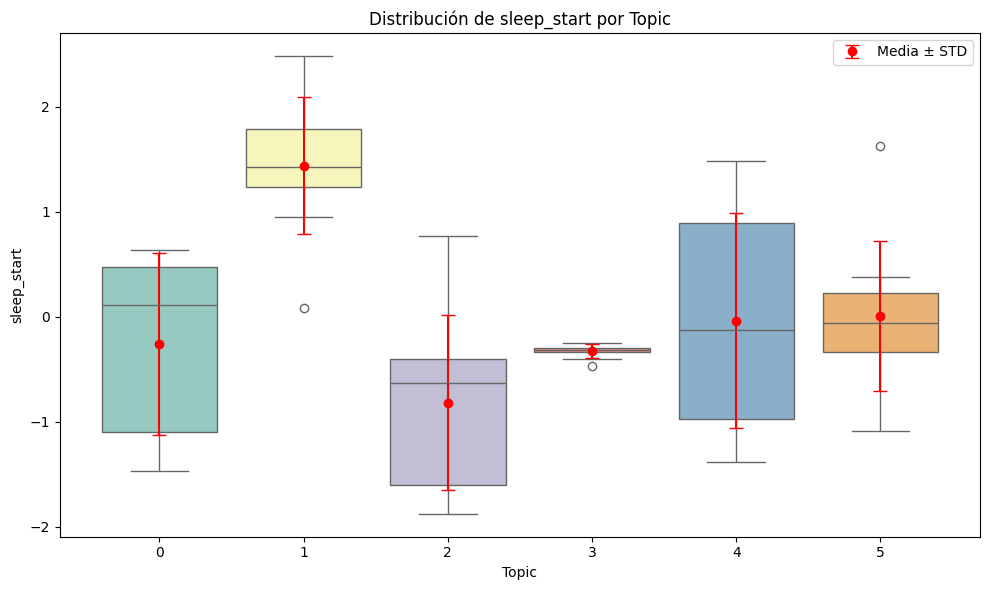

/tmp/ipykernel_2918145/3219166125.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x="topic", y=feature, palette="Set3")


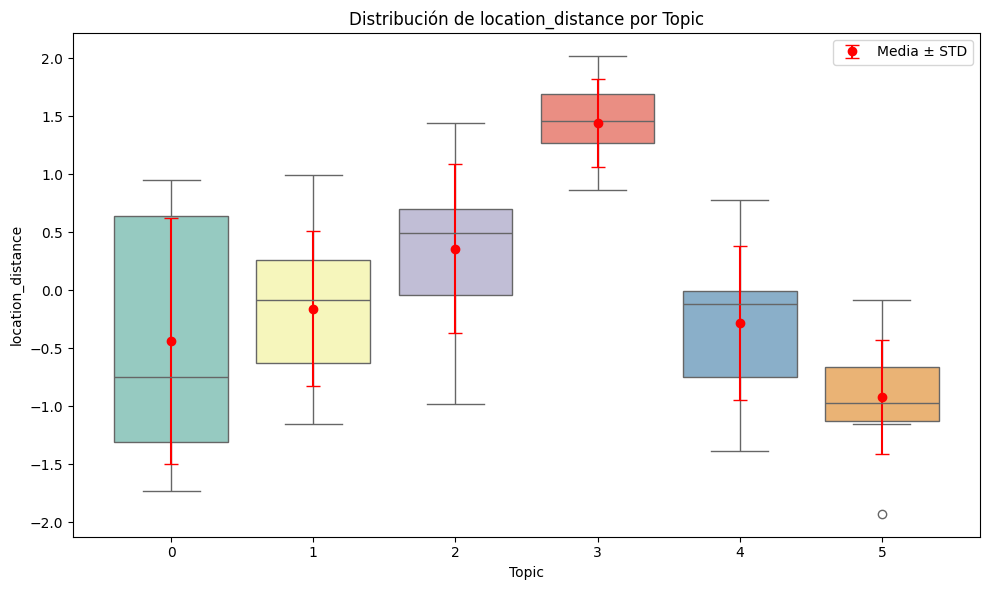

/tmp/ipykernel_2918145/3219166125.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x="topic", y=feature, palette="Set3")


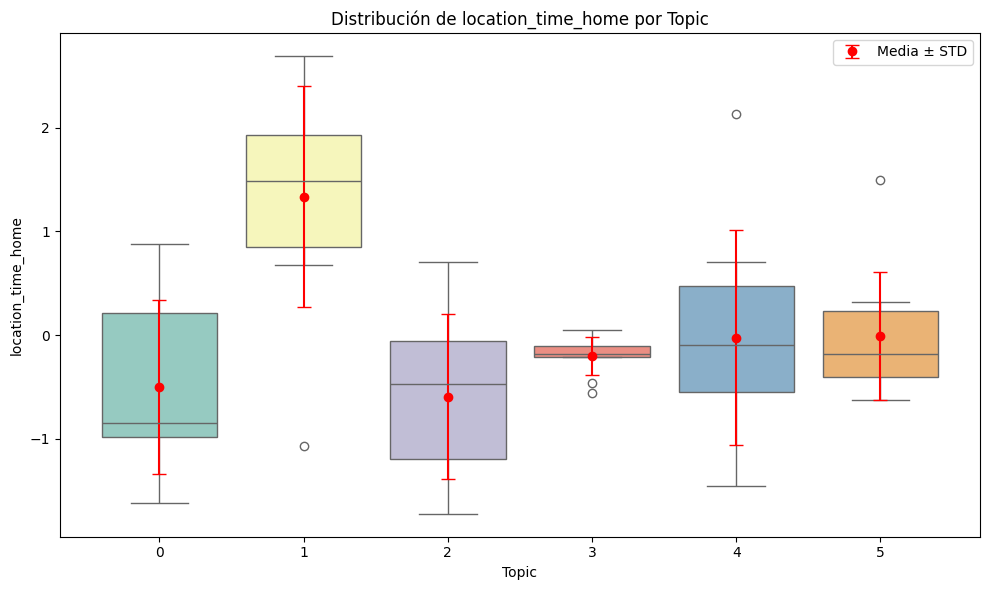

/tmp/ipykernel_2918145/3219166125.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x="topic", y=feature, palette="Set3")


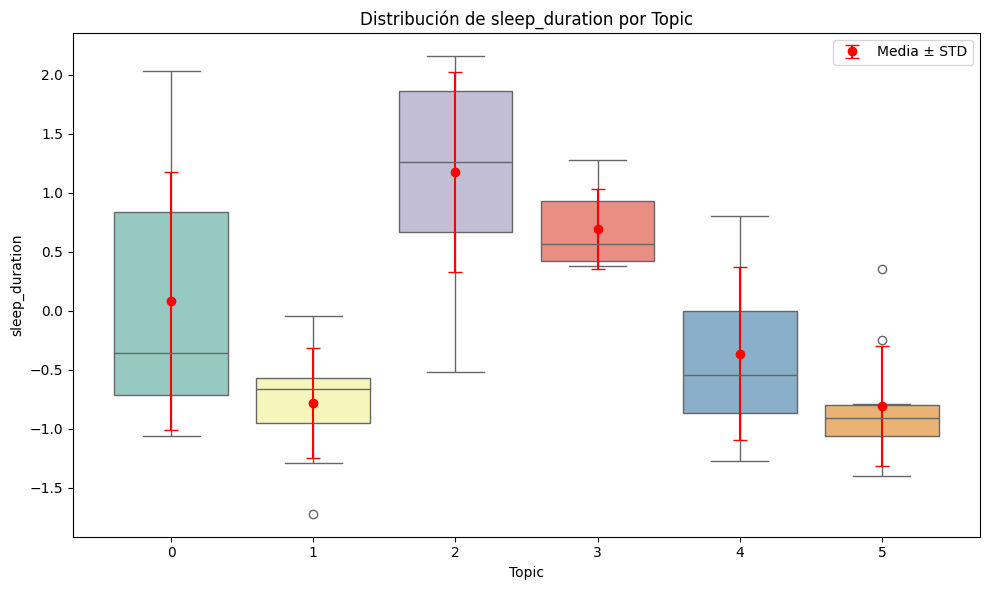

/tmp/ipykernel_2918145/3219166125.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x="topic", y=feature, palette="Set3")


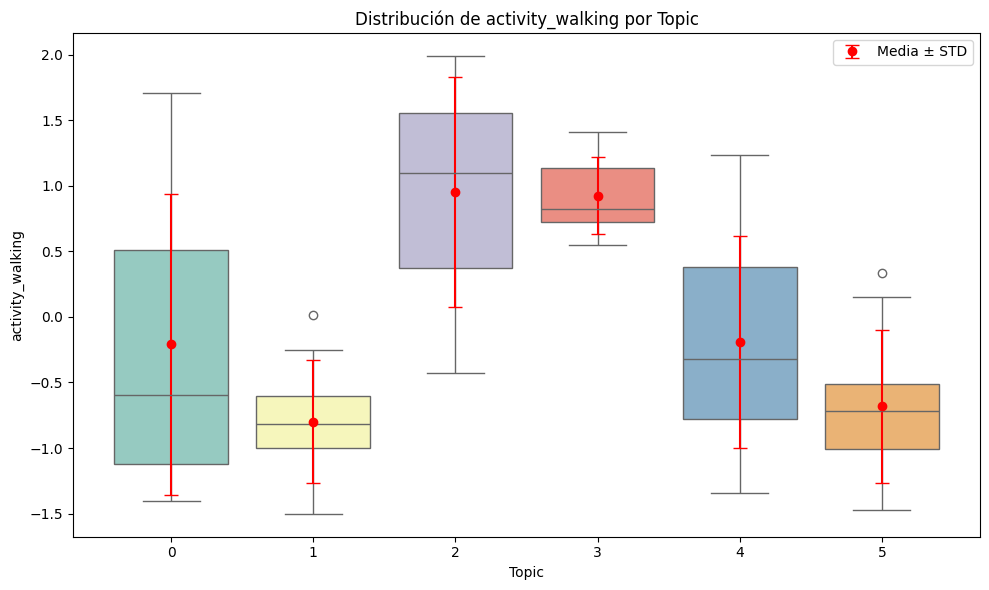

/tmp/ipykernel_2918145/3219166125.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x="topic", y=feature, palette="Set3")


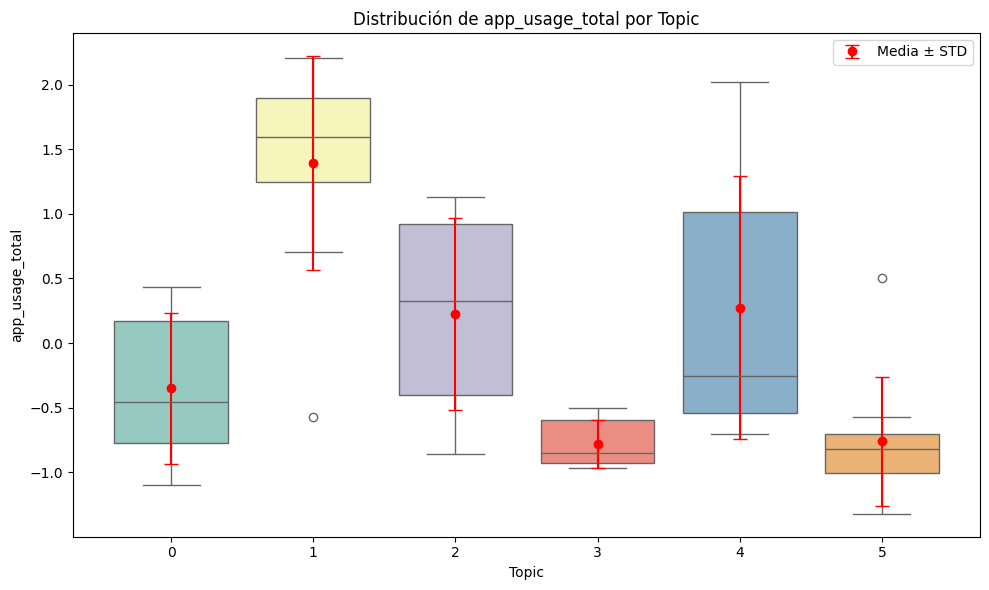

/tmp/ipykernel_2918145/3219166125.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x="topic", y=feature, palette="Set3")


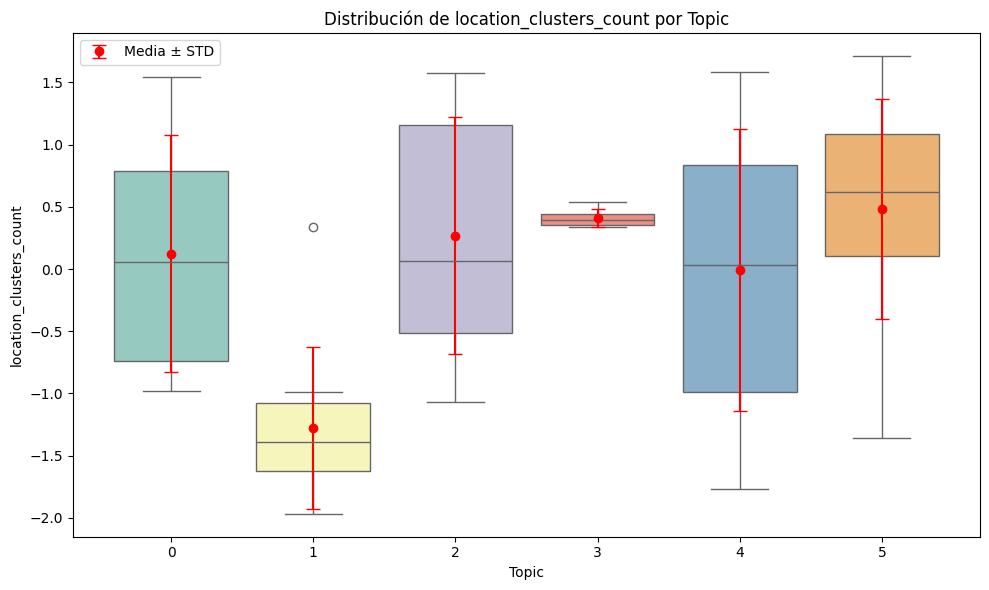

/tmp/ipykernel_2918145/3219166125.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x="topic", y=feature, palette="Set3")


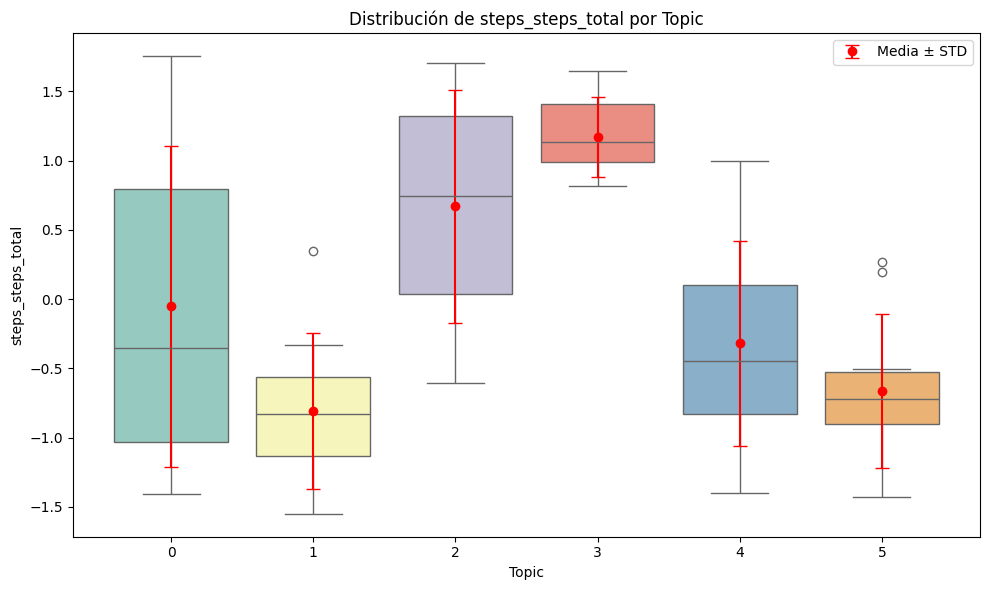

/tmp/ipykernel_2918145/3219166125.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x="topic", y=feature, palette="Set3")


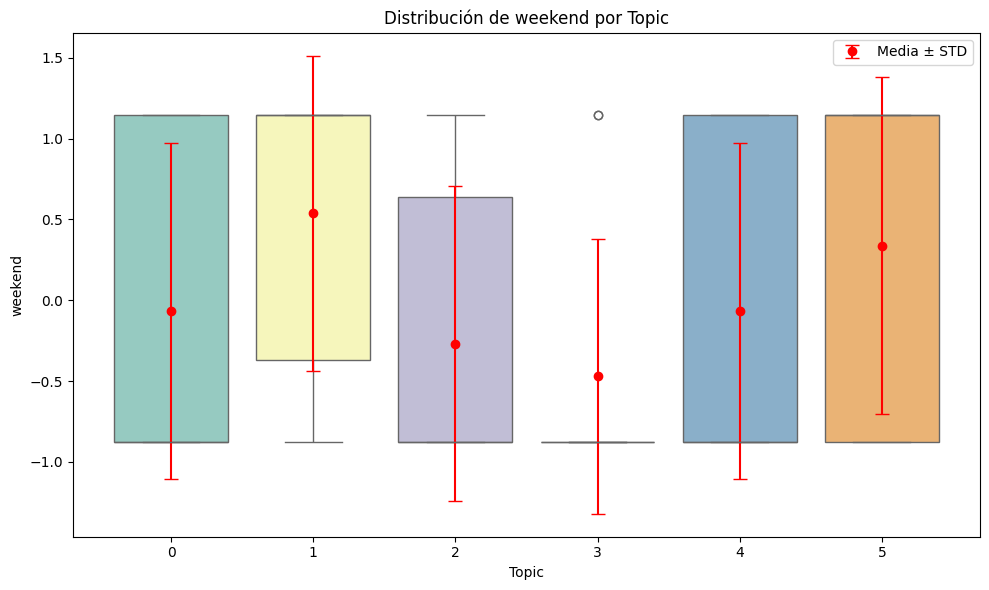

/tmp/ipykernel_2918145/3219166125.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x="topic", y=feature, palette="Set3")


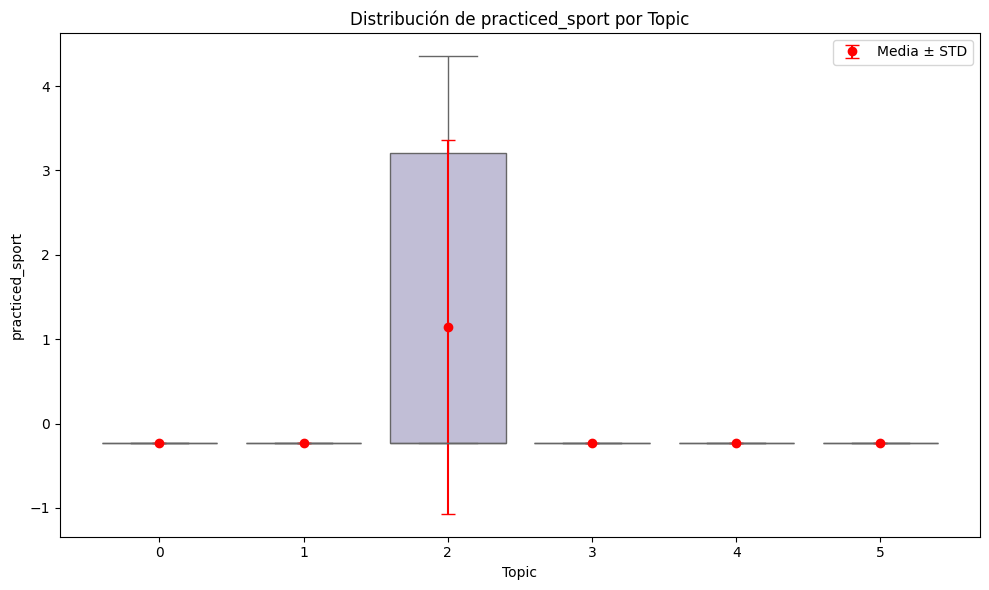

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Suponiendo que df_final y new_feature_names ya están definidos
feature_cols = new_feature_names

# Para cada feature (columna), hacemos un boxplot por topic
for feature in feature_cols:
    plt.figure(figsize=(10, 6))
    
    # Boxplot por topic
    sns.boxplot(data=df_final, x="topic", y=feature, palette="Set3")
    
    # Calcular media y desviación estándar por topic
    means = df_final.groupby("topic")[feature].mean()
    stds = df_final.groupby("topic")[feature].std()

    # Añadir la media y varianza (como barras de error)
    for i, topic in enumerate(means.index):
        plt.errorbar(i, means[topic], yerr=stds[topic], fmt='o', color='red', capsize=5, label='Media ± STD' if i == 0 else "")

    plt.title(f'Distribución de {feature} por Topic')
    plt.xlabel('Topic')
    plt.ylabel(feature)
    plt.legend()
    plt.tight_layout()
    plt.show()


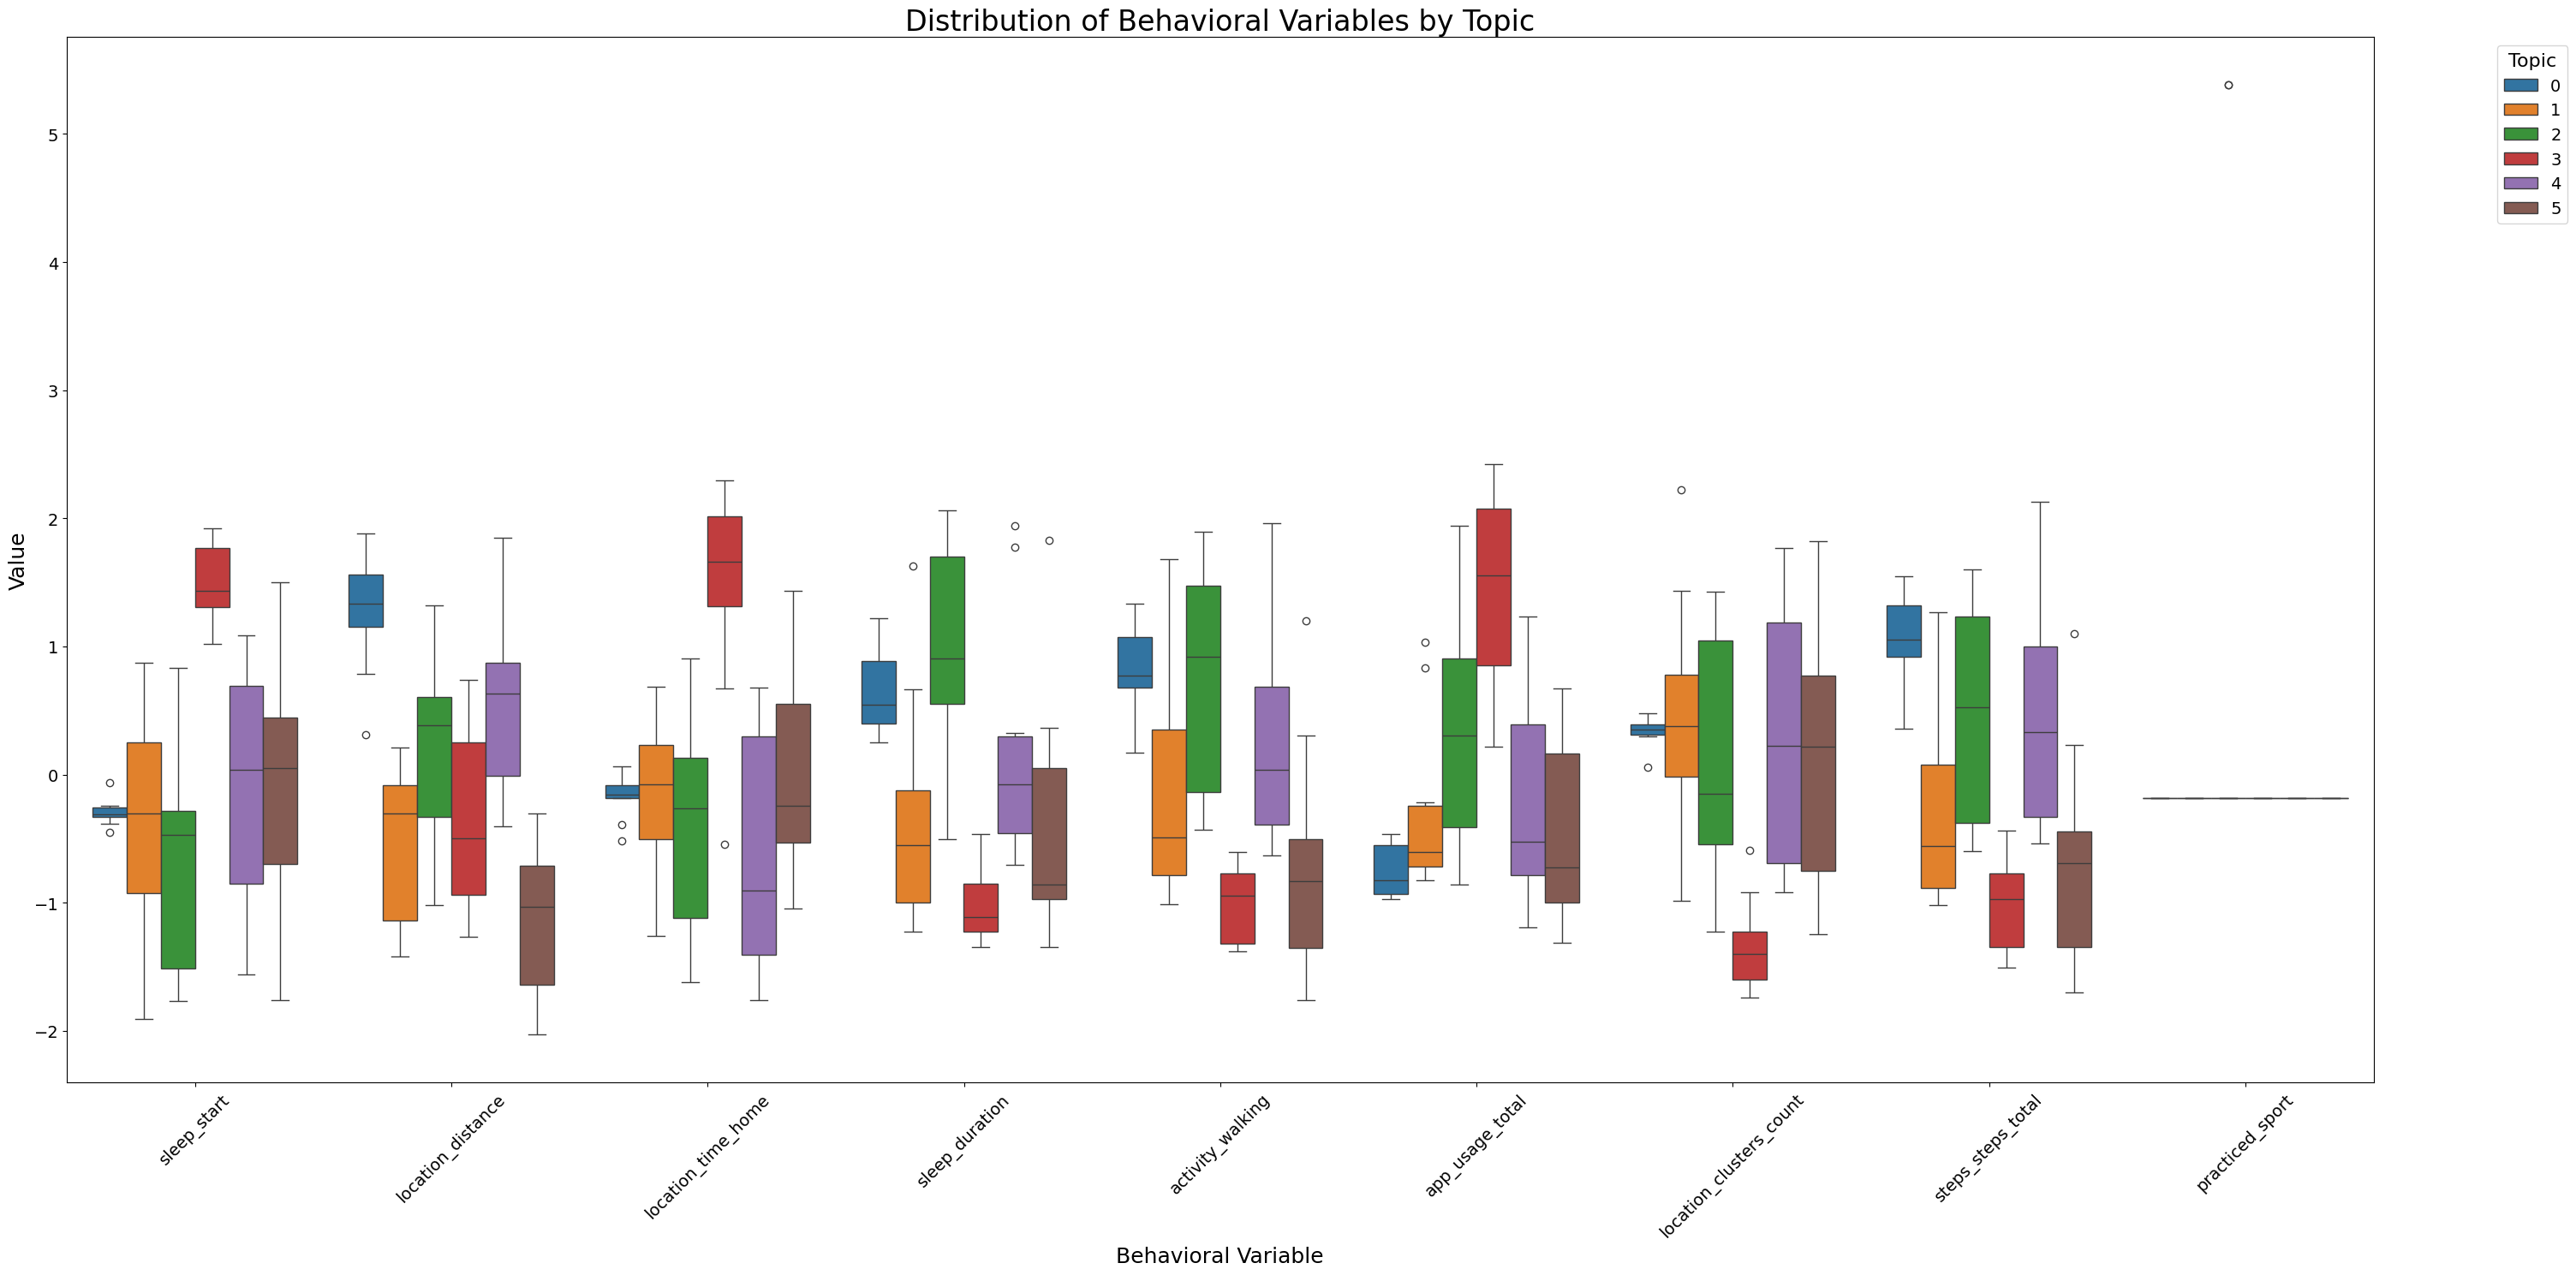

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Suponemos que df_final y new_feature_names ya están definidos
feature_cols   = [
    "sleep_start",        # feat_0
    "location_distance",  # feat_1
    "location_time_home", # feat_2
    "sleep_duration",     # feat_3
    "activity_walking",   # feat_4
    "app_usage_total",    # feat_5
    "location_clusters_count", # feat_6
    "steps_steps_total",  # feat_7
    "practiced_sport"     # feat_9
    
]

# Reorganizamos el DataFrame en formato largo para seaborn
df_melted = df_final.melt(id_vars=["topic"], value_vars=feature_cols,
                          var_name="Feature", value_name="Value")

plt.figure(figsize=(30, 15))

sns.boxplot(data=df_melted, x="Feature", y="Value", hue="topic", palette="tab10")
plt.title("Distribution of Behavioral Variables by Topic", fontsize=24)
plt.xlabel("Behavioral Variable", fontsize=18)
plt.ylabel("Value", fontsize=18)
plt.legend(title="Topic", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14, title_fontsize=16)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()


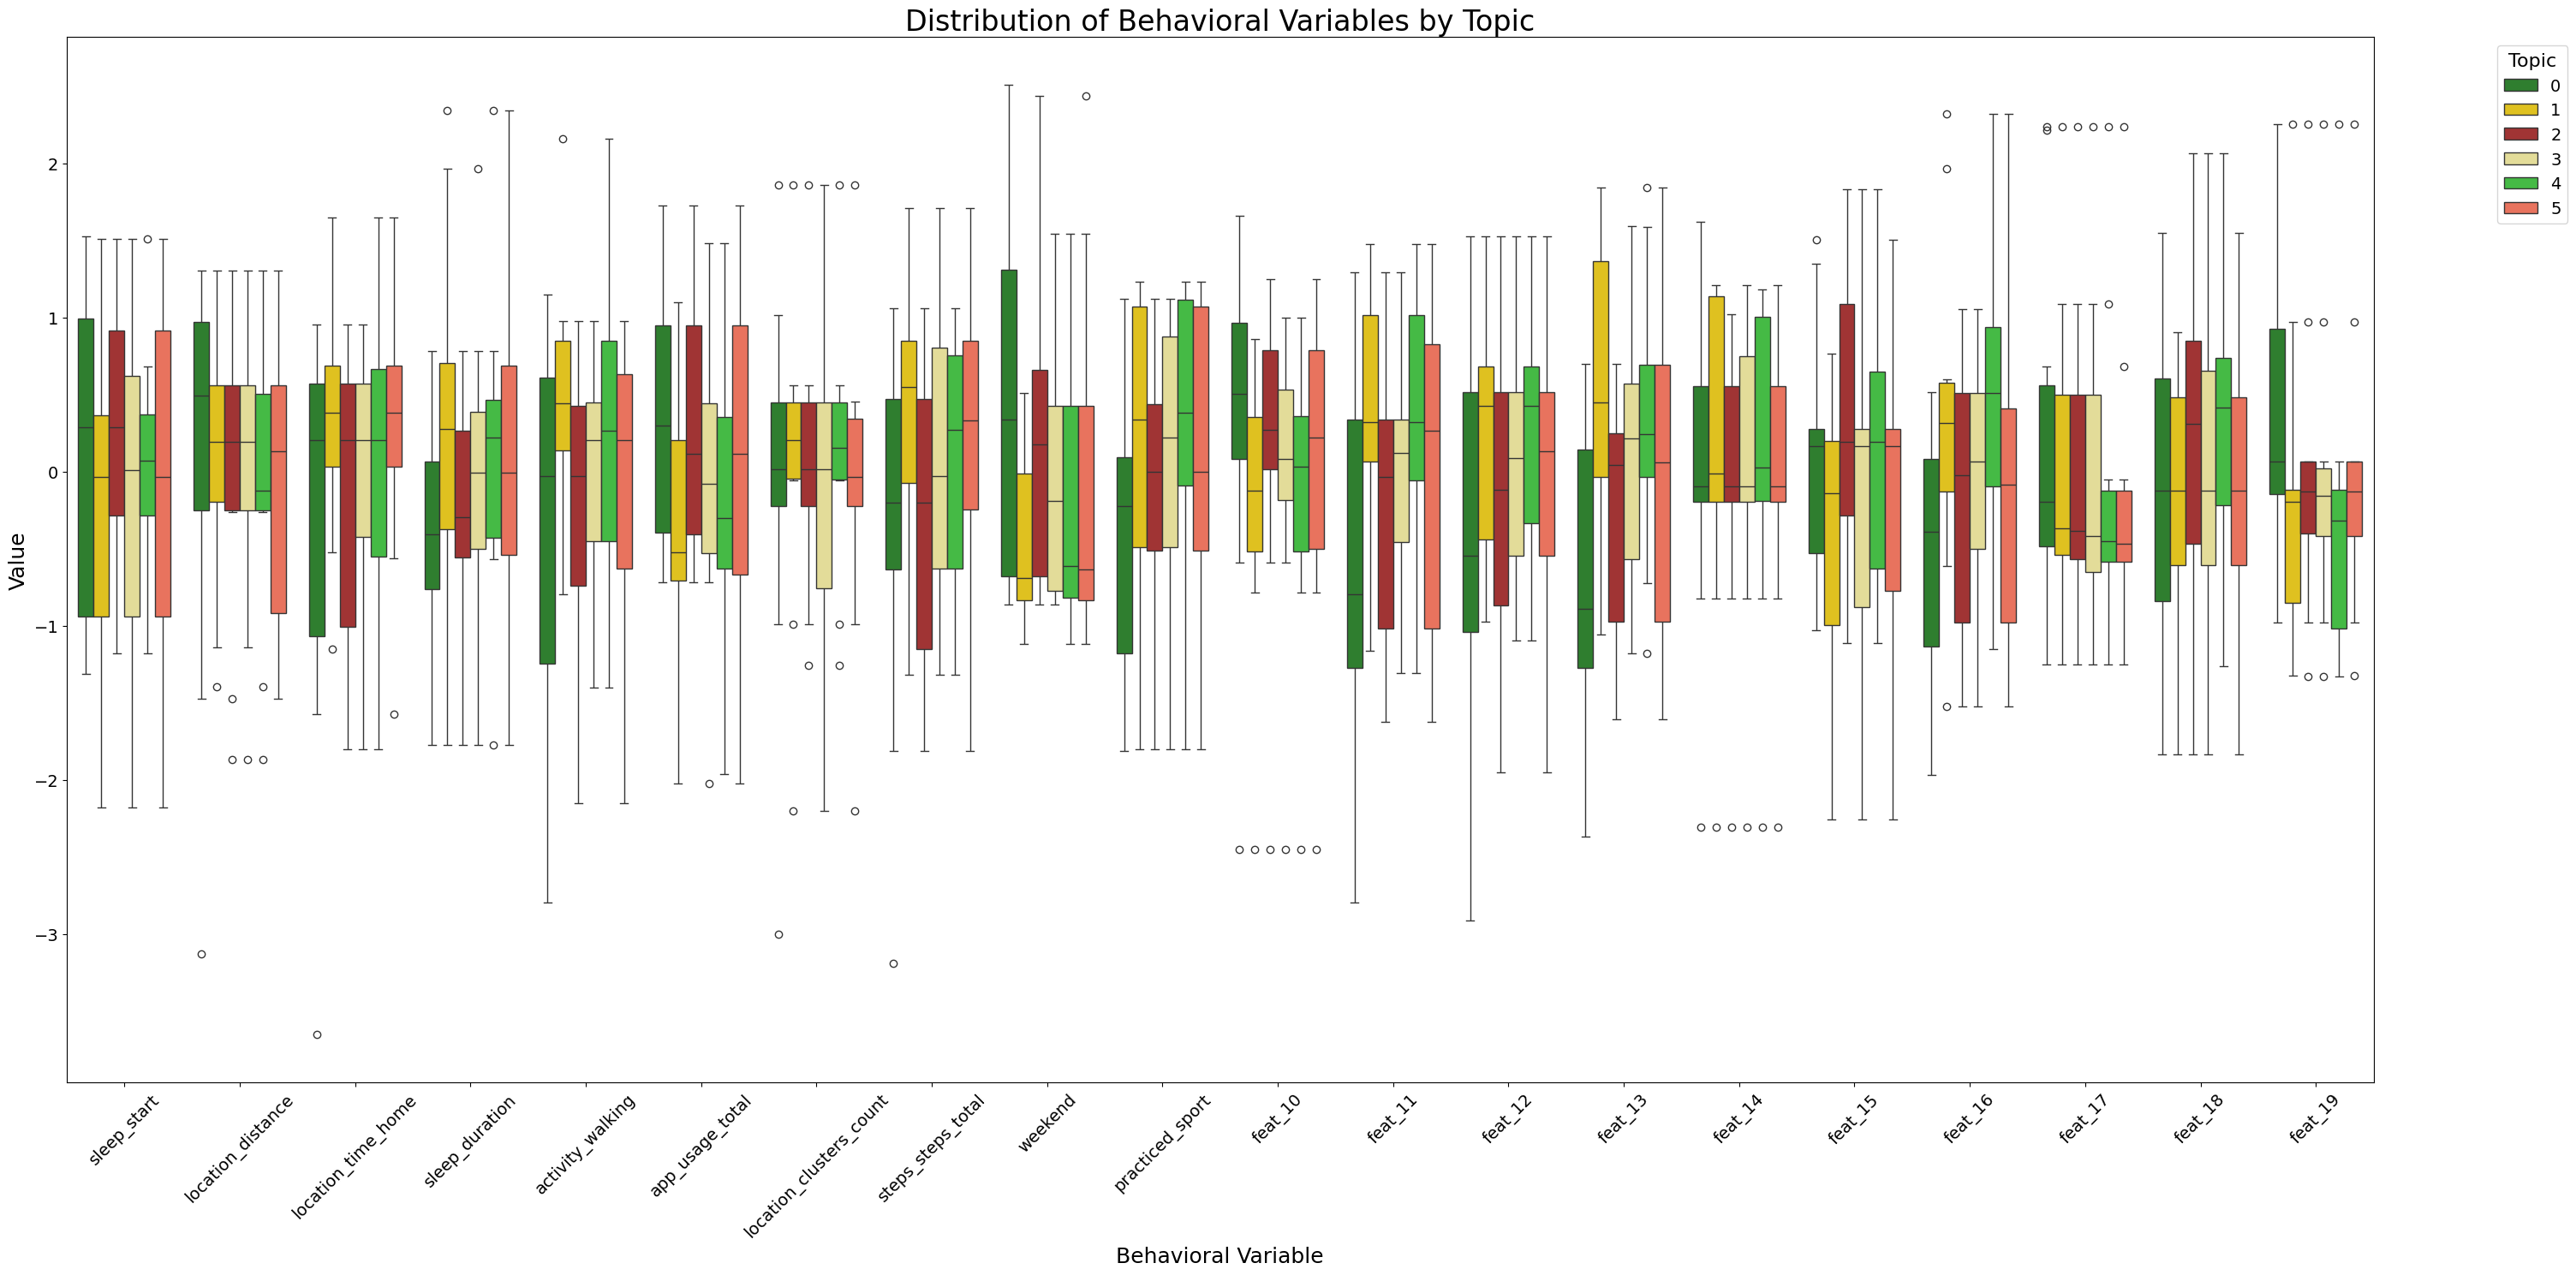

In [46]:
'''topic_colors = {
    0: "#b22222",  # rojo fuego (topic 0)
    5: "#ff6347",  # rojo tomate (topic 5)

    2: "#228b22",  # verde bosque (topic 2)
    4: "#32cd32",  # verde lima (topic 4)

    1: "#ffd700",  # amarillo dorado (topic 1)
    3: "#f0e68c",  # amarillo khaki (topic 3)
}'''

topic_colors = {
    2: "#b22222",  # rojo fuego (topic 0)
    5: "#ff6347",  # rojo tomate (topic 5)

    0: "#228b22",  # verde bosque (topic 2)
    4: "#32cd32",  # verde lima (topic 4)

    1: "#ffd700",  # amarillo dorado (topic 1)
    3: "#f0e68c",  # amarillo khaki (topic 3)
}

plt.figure(figsize=(30, 15))
sns.boxplot(
    data=df_melted,
    x="Feature",
    y="Value",
    hue="topic",
    palette=topic_colors  # <- paleta manual
)
plt.title("Distribution of Behavioral Variables by Topic", fontsize=24)
plt.xlabel("Behavioral Variable", fontsize=18)
plt.ylabel("Value", fontsize=18)
plt.legend(title="Topic", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14, title_fontsize=16)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()


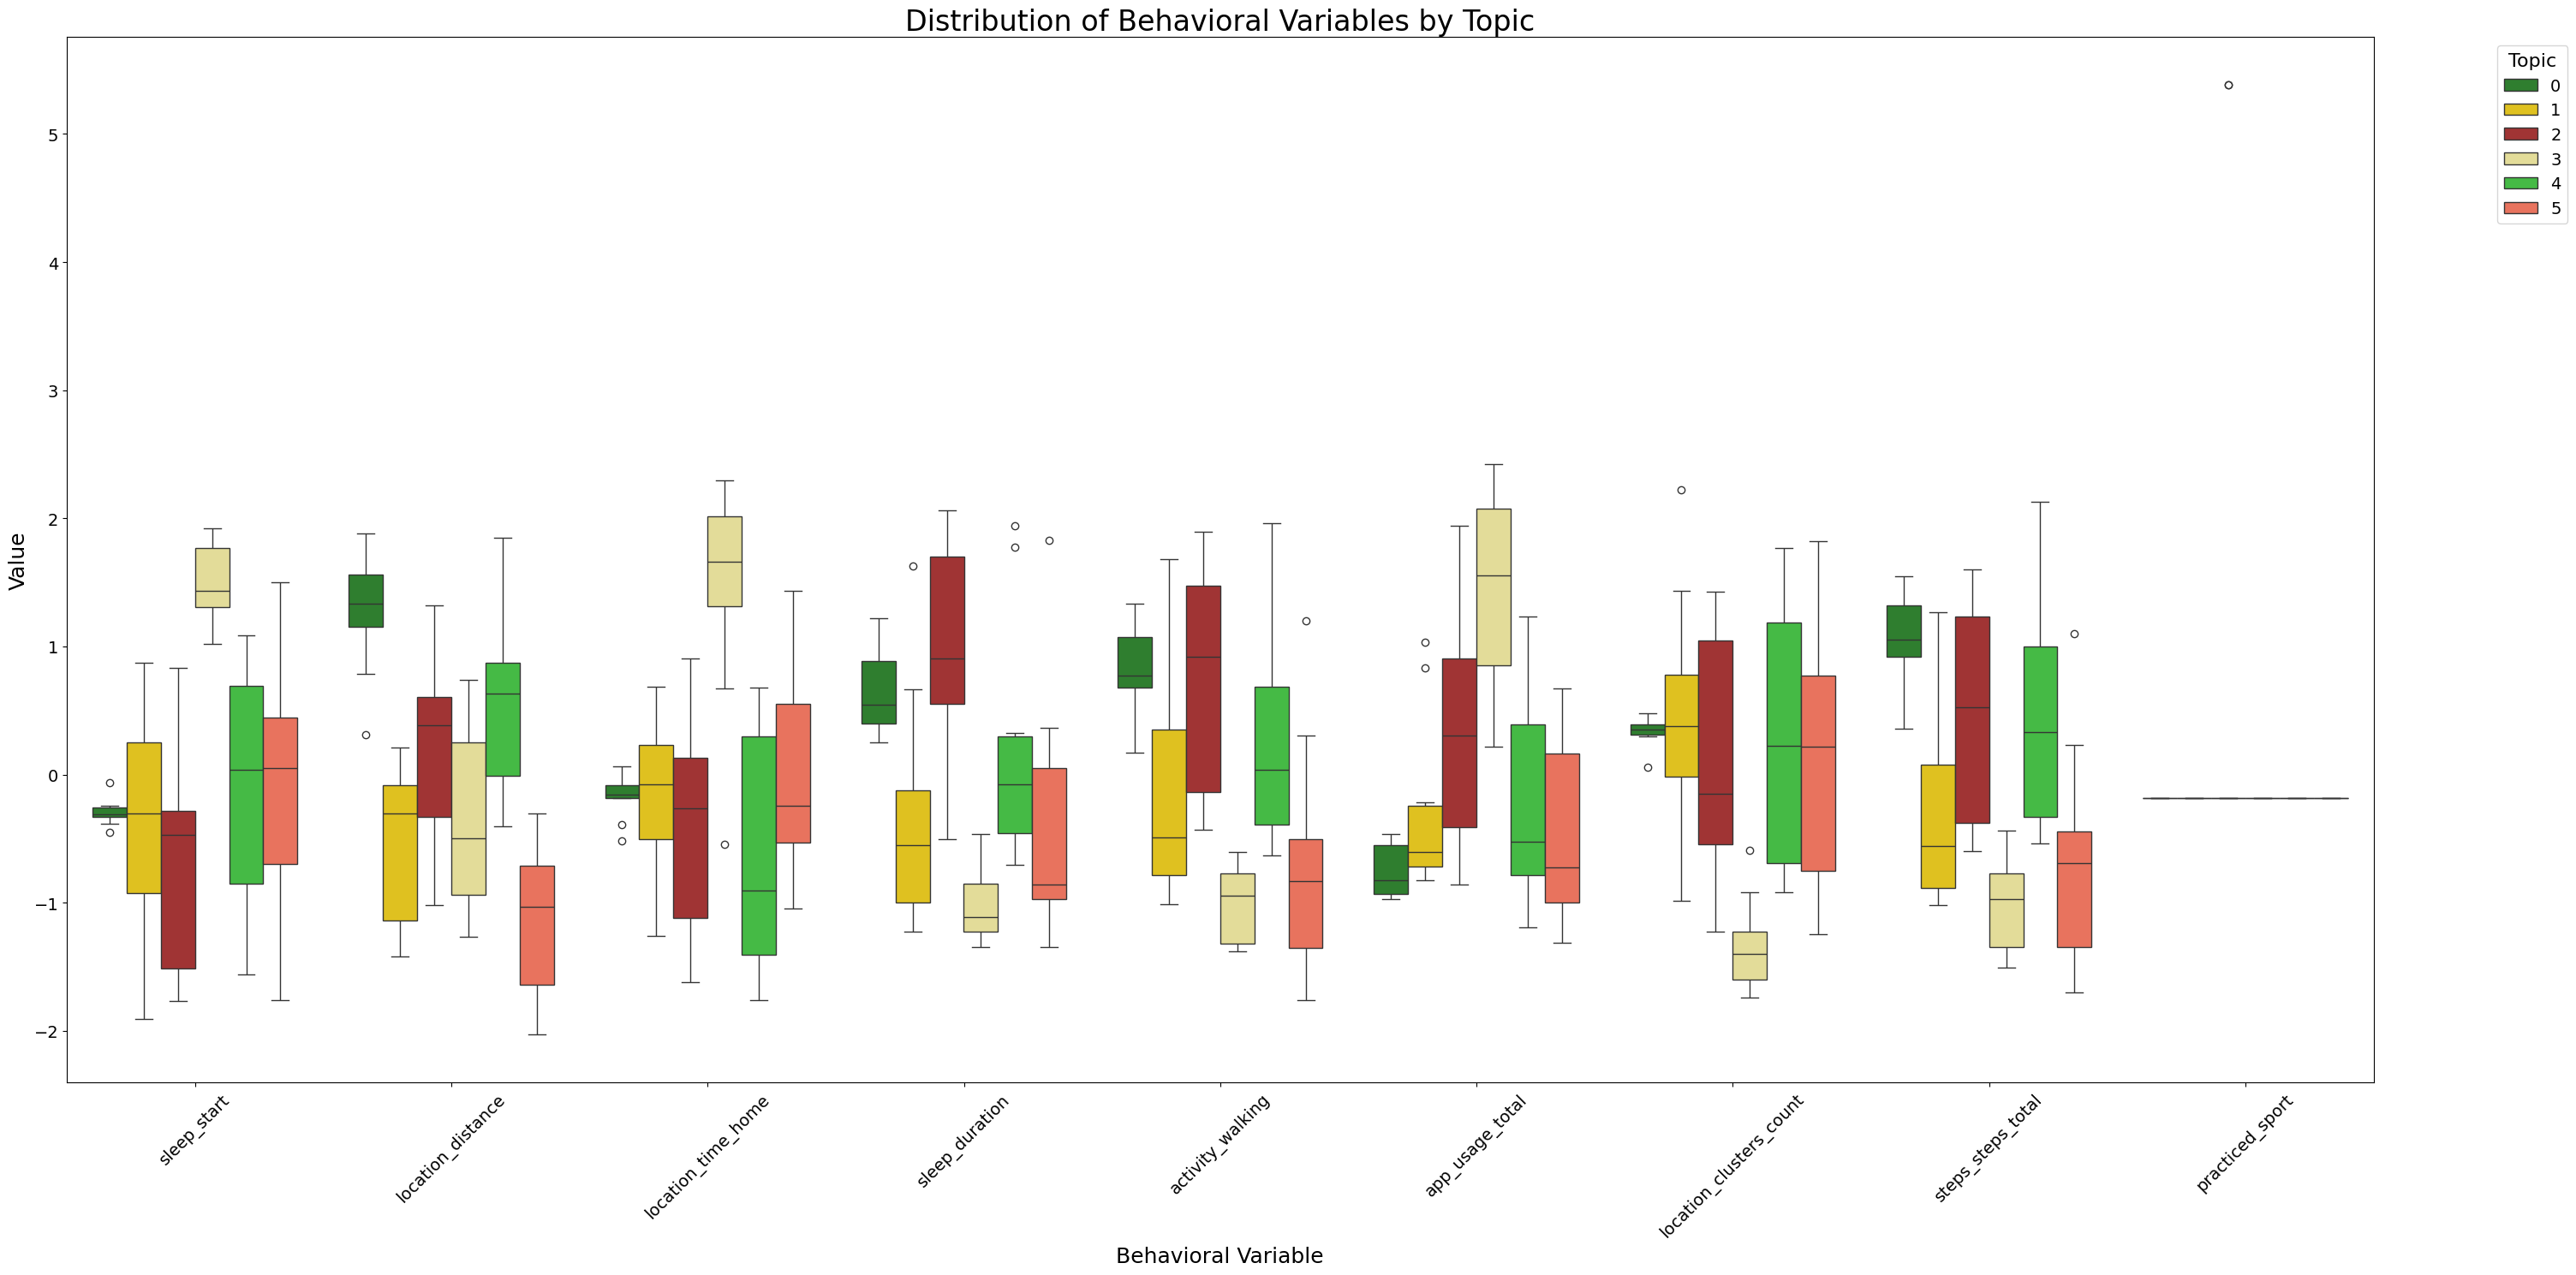

In [29]:
'''topic_colors = {
    0: "#b22222",  # rojo fuego (topic 0)
    5: "#ff6347",  # rojo tomate (topic 5)

    2: "#228b22",  # verde bosque (topic 2)
    4: "#32cd32",  # verde lima (topic 4)

    1: "#ffd700",  # amarillo dorado (topic 1)
    3: "#f0e68c",  # amarillo khaki (topic 3)
}'''

topic_colors = {
    2: "#b22222",  # rojo fuego (topic 0)
    5: "#ff6347",  # rojo tomate (topic 5)

    0: "#228b22",  # verde bosque (topic 2)
    4: "#32cd32",  # verde lima (topic 4)

    1: "#ffd700",  # amarillo dorado (topic 1)
    3: "#f0e68c",  # amarillo khaki (topic 3)
}

plt.figure(figsize=(30, 15))
sns.boxplot(
    data=df_melted,
    x="Feature",
    y="Value",
    hue="topic",
    palette=topic_colors  # <- paleta manual
)
plt.title("Distribution of Behavioral Variables by Topic", fontsize=24)
plt.xlabel("Behavioral Variable", fontsize=18)
plt.ylabel("Value", fontsize=18)
plt.legend(title="Topic", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14, title_fontsize=16)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()


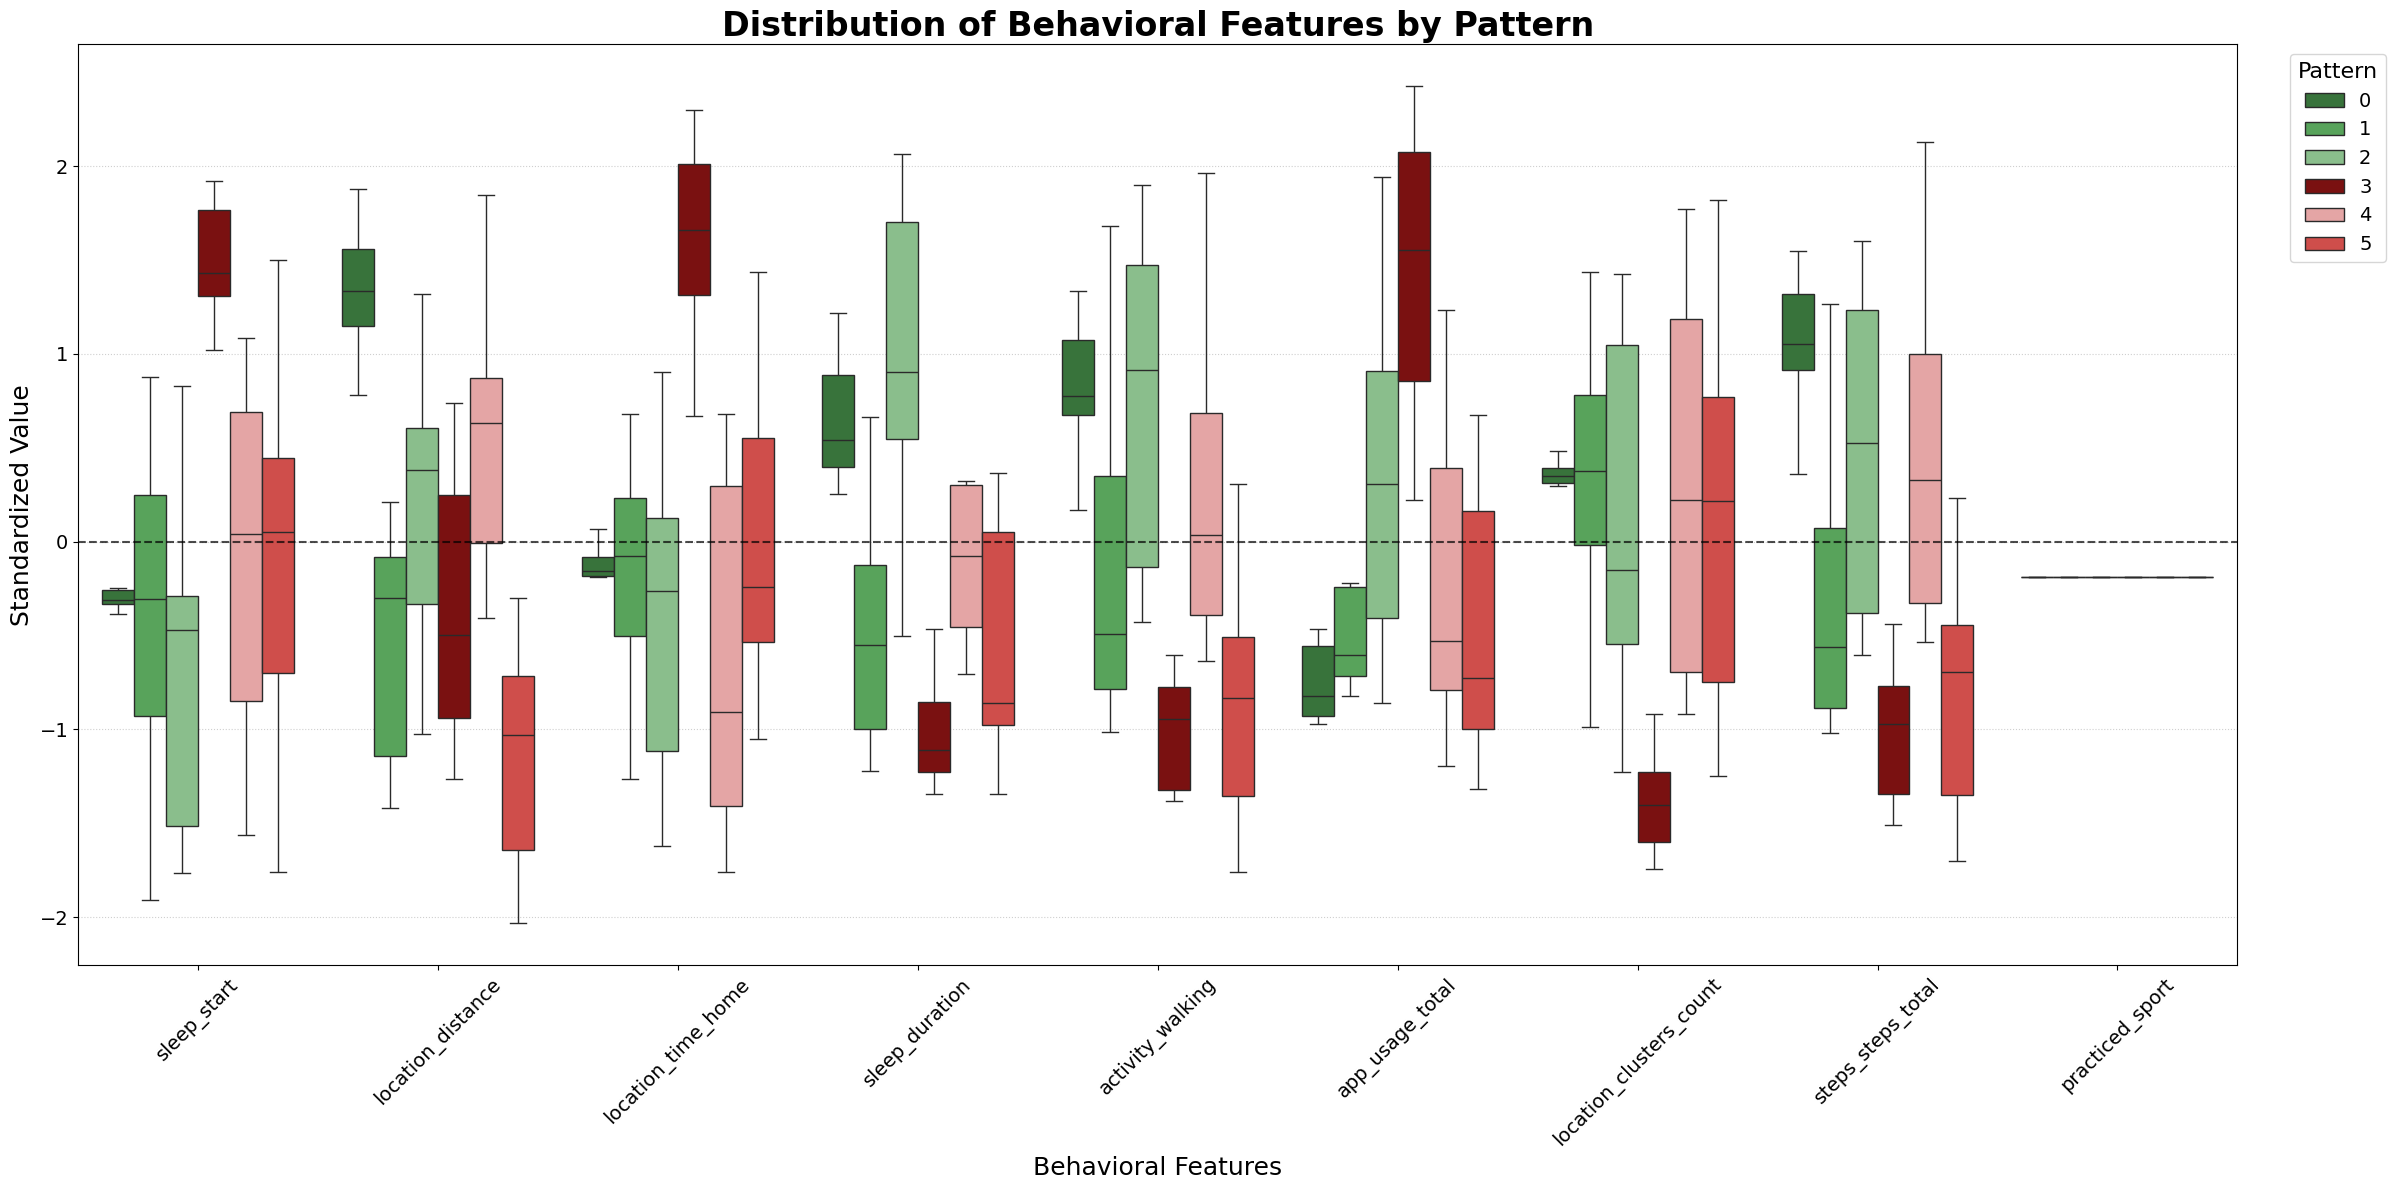

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definición manual de colores por Pattern (según tu esquema)
topic_colors = {
    0: "#2e7d32",  # Verde oscuro
    1: "#4caf50",  # Verde medio
    2: "#81c784",  # Verde claro
    
    3: "#8b0000",  # Rojo muy claro / Salmón 
    4: "#ef9a9a",  # Rojo medio
    5: "#e53935",  # Rojo muy oscuro (Dark Red)
}

# 2. Preparación del DataFrame para la gráfica
df_plot = df_melted.copy()
# Renombramos la columna 'topic' a 'Pattern' para que la leyenda sea automática
df_plot = df_plot.rename(columns={'topic': 'Pattern'})

plt.figure(figsize=(24, 12))

# 3. Creación del Boxplot
sns.boxplot(
    data=df_plot,
    x="Feature",
    y="Value",
    hue="Pattern",
    palette=topic_colors,
    showfliers=False # Opcional: oculta outliers para que la caja se vea más limpia
)

# 4. Ajustes estéticos y traducción
plt.title("Distribution of Behavioral Features by Pattern", fontsize=24, fontweight='bold')
plt.xlabel("Behavioral Features", fontsize=18)
# Confirmamos que el eje Y es el Z-score
plt.ylabel("Standardized Value", fontsize=18)

# Ajuste de leyenda
plt.legend(title="Pattern", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=14, title_fontsize=16)

# Línea en 0 para referencia clara de la media poblacional
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Boxplot guardado correctamente en: /export/gts_usuarios/lparbaiza/cnio/2nd_phase/results/decoded_topic_plots/behavioral_features_boxplot.svg


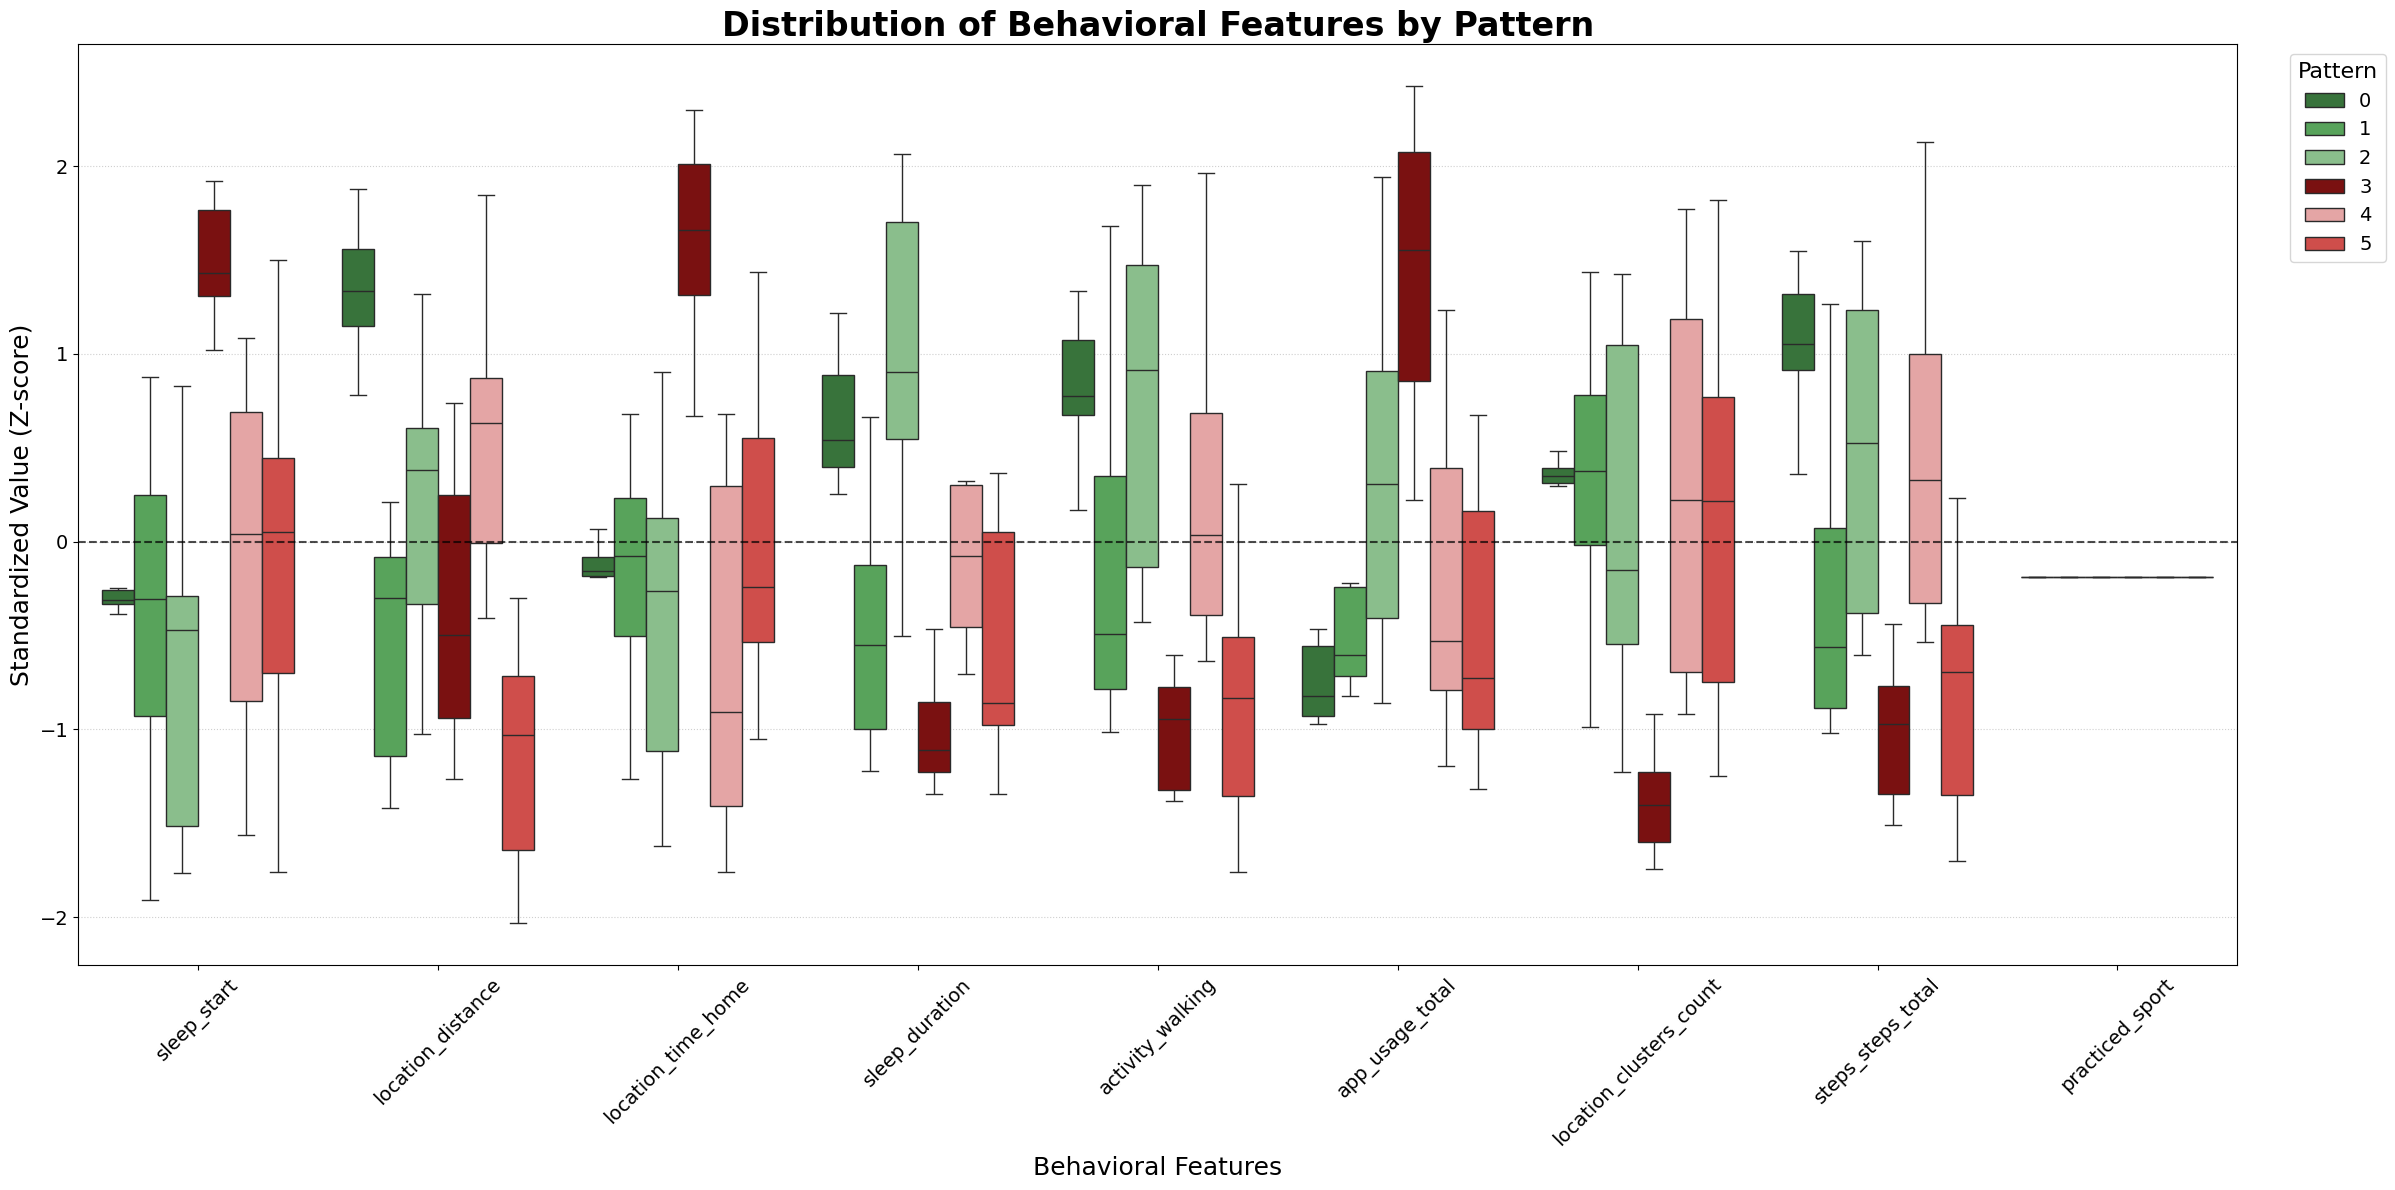

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. Definición manual de colores por Pattern
topic_colors = {
    0: "#2e7d32",  # Verde oscuro
    1: "#4caf50",  # Verde medio
    2: "#81c784",  # Verde claro
    3: "#8b0000",  # Rojo muy oscuro
    4: "#ef9a9a",  # Rojo medio
    5: "#e53935",  # Rojo brillante
}

# 2. Preparación del DataFrame
df_plot = df_melted.copy()
df_plot = df_plot.rename(columns={'topic': 'Pattern'})

# --- CAMBIO: Usamos plt.subplots para manejar mejor el guardado ---
fig, ax = plt.subplots(figsize=(24, 12))

# 3. Creación del Boxplot
sns.boxplot(
    data=df_plot,
    x="Feature",
    y="Value",
    hue="Pattern",
    palette=topic_colors,
    showfliers=False,
    ax=ax
)

# 4. Ajustes estéticos y traducción (English)
ax.set_title("Distribution of Behavioral Features by Pattern", fontsize=24, fontweight='bold')
ax.set_xlabel("Behavioral Features", fontsize=18)
ax.set_ylabel("Standardized Value (Z-score)", fontsize=18)

# Ajuste de leyenda
ax.legend(title="Pattern", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=14, title_fontsize=16)

# Línea en 0
ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

# Ajustes de ticks y grid
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
ax.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()

# -------------------------------------------
# 5 · Save as SVG (NUEVO)
# -------------------------------------------
# Definir ruta de guardado (puedes cambiar 'results' por tu carpeta)


save_path = os.path.join(save_dir, "behavioral_features_boxplot.svg")


# Guardamos la figura antes de mostrarla
fig.savefig(save_path, format='svg', bbox_inches='tight')

print(f"Boxplot guardado correctamente en: {save_path}")

# 6 · Mostrar
plt.show()